# Classificação de Ataques de Rede


In [1]:
# instalação das bibliotecas que não são nativas do Colab
# !pip install xgboost lightgbm catboost shap lime imblearn

## Importando Bibliotecas Essenciais


### Bibliotecas necessárias para as demais células do notebook


In [2]:
# -*- coding: utf-8 -*-

#from google.colab import drive

# bibliotecas padrão e manupulação/visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import time
from collections import Counter
from sklearn.manifold import TSNE
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from itertools import cycle
from sklearn.model_selection import learning_curve

# Scikit-Learn (Pré-processamento e Seleção)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif

# Métricas de Avaliação
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

# balanceamento de Dados
from imblearn.over_sampling import SMOTE

# modelos de Machine Learning para comparação
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB          # baseado em probabilistica
from xgboost import XGBClassifier                   # baseado em Boosting
from lightgbm import LGBMClassifier                 # baseado em Boosting
from catboost import CatBoostClassifier             # baseado em Boosting

# explainable AI (XAI) - Explicabilidade

import shap                                         



In [3]:
# configurações de visualização para gráficos

sns.set_context("poster", font_scale=1.0)

plt.rcParams.update({
    'font.family': 'sans-serif',   # fonte sem serifa é mais legível
    'font.size': 18,               # tamanho base da fonte muito maior
    'axes.titlesize': 24,          # título dos eixos
    'axes.labelsize': 20,          # rótulos X e Y
    'xtick.labelsize': 18,         # números do eixo X
    'ytick.labelsize': 18,         # números do eixo Y
    'legend.fontsize': 18,         # fonte da legenda
    'figure.titlesize': 28,        # título principal
    'figure.figsize': (12, 8),     # tamanho ligeiramente menor para forçar a fonte a parecer maior
    'lines.linewidth': 3,          # linhas mais grossas para visibilidade
    'lines.markersize': 12,        # marcadores maiores
    'axes.titlepad': 20,           # mais espaço entre título e gráfico
    'savefig.dpi': 300,            # garante alta resolução
    'savefig.bbox': 'tight',       # remove bordas brancas inúteis
})

In [4]:
import os
import matplotlib.pyplot as plt

# criando pasta para salvar as imagens dos gráficos para artigo
if not os.path.exists('imagens_artigo'):
    os.makedirs('imagens_artigo')
    print("Pasta 'imagens_artigo' criada com sucesso!")

Pasta 'imagens_artigo' criada com sucesso!


## Carregamento e Visão Geral dos Dados

### Carregando dataset

In [5]:
#drive.mount('/content/drive')

# data1 = pd.read_csv('/content/drive/MyDrive/CICIDS2017/Monday-WorkingHours.pcap_ISCX.csv')
# data2 = pd.read_csv('/content/drive/MyDrive/CICIDS2017/Tuesday-WorkingHours.pcap_ISCX.csv')
# data3 = pd.read_csv('/content/drive/MyDrive/CICIDS2017/Wednesday-workingHours.pcap_ISCX.csv')
# data4 = pd.read_csv('/content/drive/MyDrive/CICIDS2017/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')
# data5 = pd.read_csv('/content/drive/MyDrive/CICIDS2017/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv')
# data6 = pd.read_csv('/content/drive/MyDrive/CICIDS2017/Friday-WorkingHours-Morning.pcap_ISCX.csv')
# data7 = pd.read_csv('/content/drive/MyDrive/CICIDS2017/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')
# data8 = pd.read_csv('/content/drive/MyDrive/CICIDS2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

data1 = pd.read_csv('../CICIDS2017/Monday-WorkingHours.pcap_ISCX.csv')
data2 = pd.read_csv('../CICIDS2017/Tuesday-WorkingHours.pcap_ISCX.csv')
data3 = pd.read_csv('../CICIDS2017/Wednesday-workingHours.pcap_ISCX.csv')
data4 = pd.read_csv('../CICIDS2017/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')
data5 = pd.read_csv('../CICIDS2017/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv')
data6 = pd.read_csv('../CICIDS2017/Friday-WorkingHours-Morning.pcap_ISCX.csv')
data7 = pd.read_csv('../CICIDS2017/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')
data8 = pd.read_csv('../CICIDS2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

datalist = [data1,data2,data3,data4,data5,data6,data7,data8]

data = pd.concat(datalist) #empilhando dados

for d in datalist:
  del d # apaga cada elemento do datalist
del datalist # apaga o datalist inicial

### Análise dos dados

In [6]:
print(f"Shape dos dados: {data.shape}")
data.info()

Shape dos dados: (2830743, 79)
<class 'pandas.core.frame.DataFrame'>
Index: 2830743 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 1

In [7]:
print("Primeiras linhas dos dados:")
data.head()

Primeiras linhas dos dados:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [8]:
print("Tamanho do dataset")
print(f"Linhas: {data.shape[0]}")
print(f"Colunas: {data.shape[1]}")

Tamanho do dataset
Linhas: 2830743
Colunas: 79


## Análise Exploratória dos Dados

### Distribuição das Classes de Ataque


Distribuição das Classes de Ataque:


C:\Users\JHONATAS\AppData\Local\Temp\ipykernel_13392\3275934478.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=label_counts.index, x=label_counts.values, ax=ax, palette='viridis')


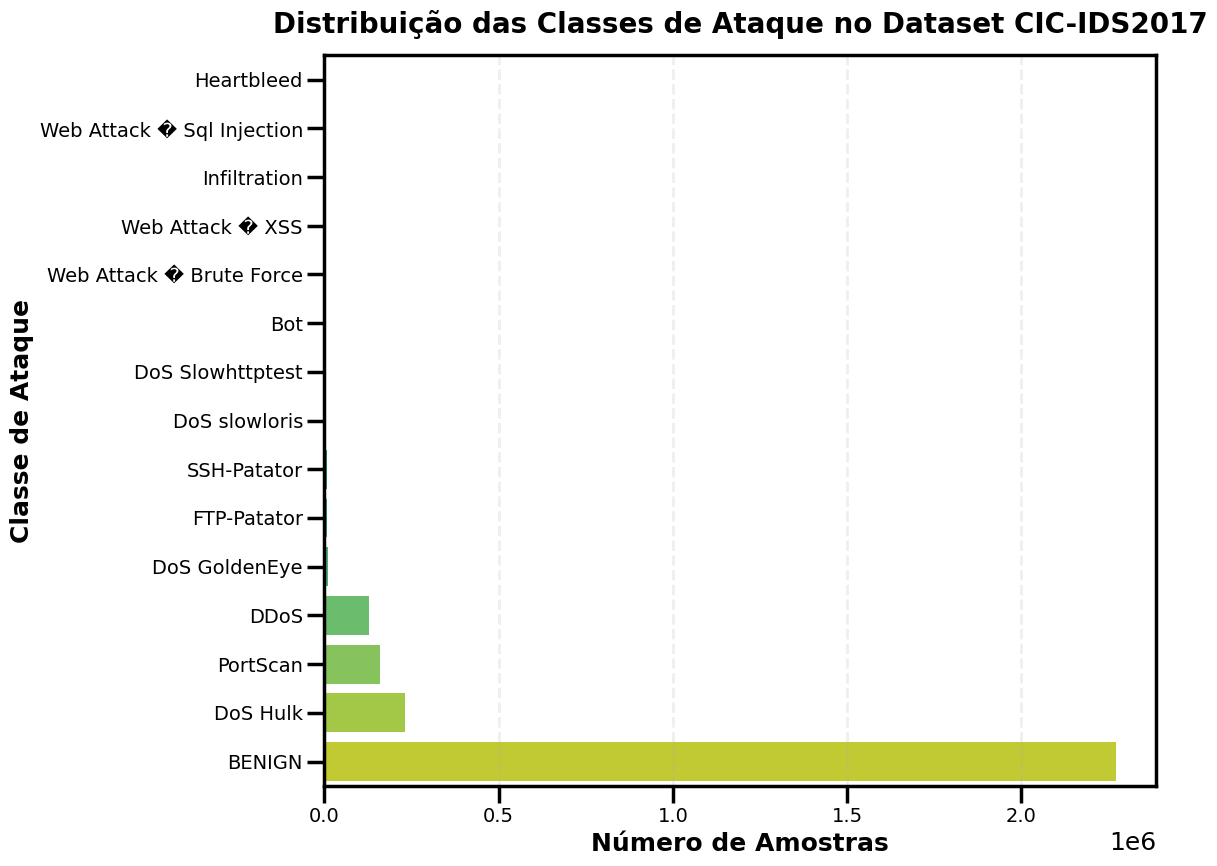

In [9]:
print("Distribuição das Classes de Ataque:")

label_counts = data[' Label'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(12, 9))
sns.barplot(y=label_counts.index, x=label_counts.values, ax=ax, palette='viridis')
ax.set_title('Distribuição das Classes de Ataque no Dataset CIC-IDS2017', fontsize=20, fontweight='bold', pad=16)
ax.set_xlabel('Número de Amostras', fontsize=18, fontweight='bold')
ax.set_ylabel('Classe de Ataque', fontsize=18, fontweight='bold')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.grid(axis='x', alpha=0.2, linestyle='--')
plt.tight_layout()
plt.savefig('imagens_artigo/distribuicao_classes_ataque.pdf', dpi=400, bbox_inches='tight')
plt.show()

### Análise dos Valores Ausentes e Infinitos

In [10]:
print("\nAnálise de Valores Ausentes:")
valores_ausentes = data.isnull().sum()
porcentagem_ausentes = (data.isnull().sum() / len(data)) * 100
missing_data = pd.DataFrame({'Contagem Ausente': valores_ausentes, 'Porcentagem Ausente (%)': porcentagem_ausentes})
print(missing_data[missing_data['Contagem Ausente'] > 0].sort_values(by='Porcentagem Ausente (%)', ascending=False))



Análise de Valores Ausentes:
              Contagem Ausente  Porcentagem Ausente (%)
Flow Bytes/s              1358                 0.047973


In [11]:
data_temp = data.replace([np.inf, -np.inf], np.nan)
count_valores_infinitos = data_temp.isnull().sum() - valores_ausentes # contagem de novos NaNs que eram infinitos
porcentagem_valores_infinitos = (count_valores_infinitos / len(data)) * 100
infinite_data = pd.DataFrame({'Contagem Infinitos': count_valores_infinitos, 'Porcentagem Infinitos (%)': porcentagem_valores_infinitos})
print("\nAnálise de Valores Infinitos:")
print(infinite_data[infinite_data['Contagem Infinitos'] > 0].sort_values(by='Porcentagem Infinitos (%)', ascending=False))



Análise de Valores Infinitos:
                 Contagem Infinitos  Porcentagem Infinitos (%)
 Flow Packets/s                2867                   0.101281
Flow Bytes/s                   1509                   0.053308


## Organizando nome das colunas

### Removendo espaços, pontos, barras, hífens e converter letras para minúsculas


In [12]:
# removendo espaços, pontos, barras, hífens e converter letras para minúsculas
data.columns = data.columns.str.lower().str.strip().str.replace(' ', '_').str.replace('.', '', regex=False).str.replace('/', '_').str.replace('-', '_')
print(f"Nomes de colunas padronizados (primeiros 5): {data.columns.tolist()[:5]}")

Nomes de colunas padronizados (primeiros 5): ['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets']


### Traduzindo nome das colunas para Português

In [13]:
colunas_traducao = {
    'destination_port': 'porta_destino',
    'flow_duration': 'duracao_fluxo',
    'total_fwd_packets': 'total_pacotes_fwd',
    'total_backward_packets': 'total_pacotes_bwd',
    'total_length_of_fwd_packets': 'tamanho_total_pacotes_fwd',
    'total_length_of_bwd_packets': 'tamanho_total_pacotes_bwd',
    'fwd_packet_length_max': 'tam_pacote_fwd_max',
    'fwd_packet_length_min': 'tam_pacote_fwd_min',
    'fwd_packet_length_mean': 'tam_pacote_fwd_media',
    'fwd_packet_length_std': 'tam_pacote_fwd_std',
    'bwd_packet_length_max': 'tam_pacote_bwd_max',
    'bwd_packet_length_min': 'tam_pacote_bwd_min',
    'bwd_packet_length_mean': 'tam_pacote_bwd_media',
    'bwd_packet_length_std': 'tam_pacote_bwd_std',
    'flow_bytes_s': 'fluxo_bytes_s',
    'flow_packets_s': 'fluxo_pacotes_s',
    'flow_iat_mean': 'fluxo_iat_media',
    'flow_iat_std': 'fluxo_iat_std',
    'flow_iat_max': 'fluxo_iat_max',
    'flow_iat_min': 'fluxo_iat_min',
    'fwd_iat_total': 'fwd_iat_total',
    'fwd_iat_mean': 'fwd_iat_media',
    'fwd_iat_std': 'fwd_iat_std',
    'fwd_iat_max': 'fwd_iat_max',
    'fwd_iat_min': 'fwd_iat_min',
    'bwd_iat_total': 'bwd_iat_total',
    'bwd_iat_mean': 'bwd_iat_media',
    'bwd_iat_std': 'bwd_iat_std',
    'bwd_iat_max': 'bwd_iat_max',
    'bwd_iat_min': 'bwd_iat_min',
    'fwd_psh_flags': 'fwd_psh_flags',
    'bwd_psh_flags': 'bwd_psh_flags',
    'fwd_urg_flags': 'fwd_urg_flags',
    'bwd_urg_flags': 'bwd_urg_flags',
    'fwd_header_length': 'tam_cabecalho_fwd',
    'bwd_header_length': 'tam_cabecalho_bwd',
    'fwd_packets_s': 'fwd_pacotes_s',
    'bwd_packets_s': 'bwd_pacotes_s',
    'min_packet_length': 'tam_pacote_min',
    'max_packet_length': 'tam_pacote_max',
    'packet_length_mean': 'tam_pacote_media',
    'packet_length_std': 'tam_pacote_std',
    'packet_length_variance': 'variancia_tam_pacote',
    'fin_flag_count': 'contagem_fin_flag',
    'syn_flag_count': 'contagem_syn_flag',
    'rst_flag_count': 'contagem_rst_flag',
    'psh_flag_count': 'contagem_psh_flag',
    'ack_flag_count': 'contagem_ack_flag',
    'urg_flag_count': 'contagem_urg_flag',
    'cwe_flag_count': 'contagem_cwe_flag',
    'ece_flag_count': 'contagem_ece_flag',
    'down_up_ratio': 'down_up_ratio',
    'average_packet_size': 'tam_medio_pacote',
    'avg_fwd_segment_size': 'tam_medio_segmento_fwd',
    'avg_bwd_segment_size': 'tam_medio_segmento_bwd',
    'fwd_header_length1': 'tam_cabecalho_fwd1',
    'fwd_avg_bytes_bulk': 'fwd_bytes_bulk_media',
    'fwd_avg_packets_bulk': 'fwd_pacotes_bulk_media',
    'fwd_avg_bulk_rate': 'fwd_taxa_bulk_media',
    'bwd_avg_bytes_bulk': 'bwd_bytes_bulk_media',
    'bwd_avg_packets_bulk': 'bwd_pacotes_bulk_media',
    'bwd_avg_bulk_rate': 'bwd_taxa_bulk_media',
    'subflow_fwd_packets': 'subfluxo_pacotes_fwd',
    'subflow_fwd_bytes': 'subfluxo_bytes_fwd',
    'subflow_bwd_packets': 'subfluxo_pacotes_bwd',
    'subflow_bwd_bytes': 'subfluxo_bytes_bwd',
    'init_win_bytes_forward': 'bytes_janela_inicial_fwd',
    'init_win_bytes_backward': 'bytes_janela_inicial_bwd',
    'act_data_pkt_fwd': 'pacotes_dados_ativos_fwd',
    'min_seg_size_forward': 'tam_min_segmento_fwd',
    'active_mean': 'media_ativo',
    'active_std': 'std_ativo',
    'active_max': 'max_ativo',
    'active_min': 'min_ativo',
    'idle_mean': 'media_ocioso',
    'idle_std': 'std_ocioso',
    'idle_max': 'max_ocioso',
    'idle_min': 'min_ocioso',
    'label': 'rotulo'
}

if 'label' in data.columns:
    data.rename(columns={'label': 'rotulo'}, inplace=True)
elif '_label' in data.columns:
    data.rename(columns={'_label': 'rotulo'}, inplace=True)
elif ' Label' in data.columns:
    data.rename(columns={' Label': 'rotulo'}, inplace=True)

if 'label' in colunas_traducao:
    del colunas_traducao['label']

data.rename(columns=colunas_traducao, inplace=True)


## Pré-Processamento dos dados

### Substituir valores infinitos (positivos e negativos) por NaN


In [14]:
print("Número de linhas com valores infinitos:")
print(data.isin([np.inf, -np.inf]).any(axis=1).sum())

Número de linhas com valores infinitos:
2867


In [15]:
print("Substituindo valores infinitos por NaN (valor ausente)")
data.replace([np.inf, -np.inf], np.nan, inplace=True) # substitui por NAN (valor ausente)

Substituindo valores infinitos por NaN (valor ausente)


### Remover linhas com valores ausentes (NaN)

In [16]:
print(f"Número de linhas antes da remoção de NaNs: {len(data)}")
print(f"Número de linhas com valores ausentes: {data.isnull().any(axis=1).sum()}")
data.dropna(inplace=True)
print('\nLinhas com NaN removidas\n')
print(f"Número de linhas após remoção de NaNs: {len(data)}")
print(f"Total de NaNs após a remoção: {data.isnull().sum().sum()}")

Número de linhas antes da remoção de NaNs: 2830743
Número de linhas com valores ausentes: 2867

Linhas com NaN removidas

Número de linhas após remoção de NaNs: 2827876
Total de NaNs após a remoção: 0


### Remover linhas duplicadas

In [17]:
print('Quantidade de linhas duplicadas: '+ str(data.duplicated().sum()))
data.drop_duplicates(inplace=True)
print('Linhas duplicadas removidas. \nQuantidade após remoção: '+ str(data.duplicated().sum()))

Quantidade de linhas duplicadas: 307078
Linhas duplicadas removidas. 
Quantidade após remoção: 0


### Limpeza dos Rótulos (Label)

In [18]:
data['rotulo'] = data['rotulo'].str.replace('�', '-') # para substituir por -
data['rotulo'] = data['rotulo'].str.strip() # remover espaços em branco
print("Valores únicos na coluna 'rotulo' após strip:", data['rotulo'].unique())

Valores únicos na coluna 'rotulo' após strip: ['BENIGN' 'FTP-Patator' 'SSH-Patator' 'DoS slowloris' 'DoS Slowhttptest'
 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed' 'Web Attack - Brute Force'
 'Web Attack - XSS' 'Web Attack - Sql Injection' 'Infiltration' 'Bot'
 'PortScan' 'DDoS']


## Balanceamento Das Classes

### Distribuição das classes

In [19]:
print("Distribuição de rótulos antes da codificação:")
print(data['rotulo'].value_counts())

Distribuição de rótulos antes da codificação:
rotulo
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack - Brute Force         1470
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


### Balanceando Classes (agrupamento)

In [20]:
ataques_agrupados = {
    'BENIGN': 'Benigno', # Classe de Tráfego Normal

    # DoS/DDoS: classe de Negação de Serviço (Volumétrica)
    'DoS Hulk': 'DoS/DDoS',
    'DDoS': 'DoS/DDoS',
    'DoS GoldenEye': 'DoS/DDoS',
    'DoS slowloris': 'DoS/DDoS',
    'DoS Slowhttptest': 'DoS/DDoS',

    # PortScan: Reconhecimento
    'PortScan': 'PortScan',

    # Força Bruta (Rede)
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',

    # Ataques Web
    'Web Attack - Brute Force': 'Web Attack',
    'Web Attack - XSS': 'Web Attack',
    'Web Attack - Sql Injection': 'Web Attack',

    # Bot/Infiltration - Ameaças Avançadas/Raras
    'Bot': 'Bot/Infiltration',
    'Infiltration': 'Bot/Infiltration',
    'Heartbleed': 'Bot/Infiltration'
}

data['rotulo'] = data['rotulo'].map(ataques_agrupados)


### Verificação da Distribuição de Classes após Balanceamento

Balanceamento feito por Agrupamento de ataques de mesma natureza

In [21]:
print("Balanceamento de classes após agrupamento:")
print(data['rotulo'].value_counts())

Balanceamento de classes após agrupamento:
rotulo
Benigno             2095057
DoS/DDoS             321759
PortScan              90694
Brute Force            9150
Web Attack             2143
Bot/Infiltration       1995
Name: count, dtype: int64


### Distribuição das Classes de Ataque após Balanceamento por Agrupamento

Distribuição das Classes de Ataque:


C:\Users\JHONATAS\AppData\Local\Temp\ipykernel_13392\1603610556.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=label_counts.index, x=label_counts.values, ax=ax, palette='viridis')


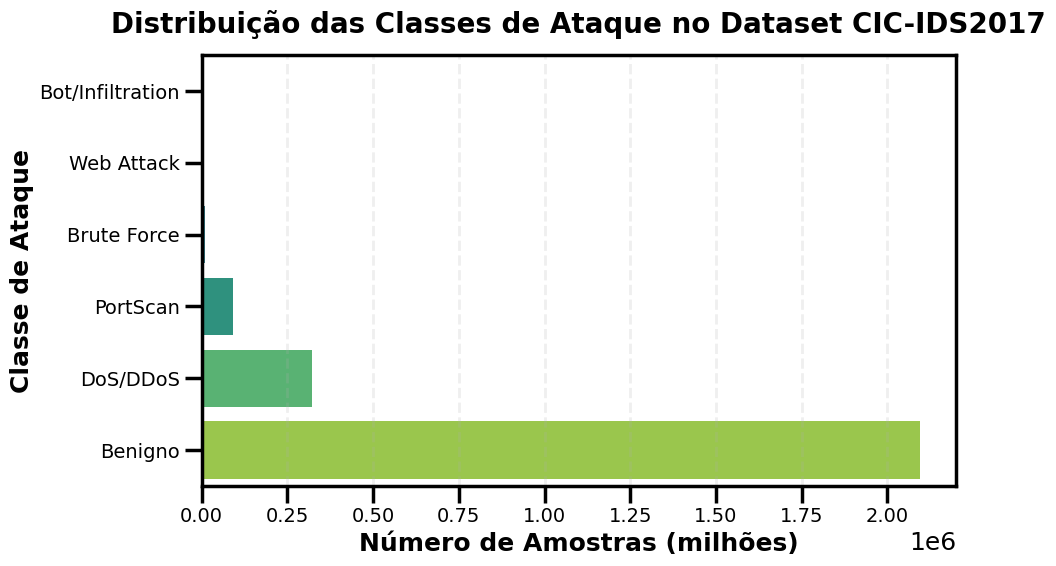

In [22]:
print("Distribuição das Classes de Ataque:")

label_counts = data['rotulo'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(y=label_counts.index, x=label_counts.values, ax=ax, palette='viridis')
ax.set_title('Distribuição das Classes de Ataque no Dataset CIC-IDS2017', fontsize=20, fontweight='bold', pad=16)
ax.set_xlabel('Número de Amostras (milhões)', fontsize=18, fontweight='bold')
ax.set_ylabel('Classe de Ataque', fontsize=18, fontweight='bold')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.grid(axis='x', alpha=0.2, linestyle='--')
plt.tight_layout()
plt.savefig('imagens_artigo/distribuicao_classes_ataque(após_agrupamento).pdf', dpi=400, bbox_inches='tight')
plt.show()

## Separação dos Dados

### Separação das features e target

In [23]:
X = data.drop('rotulo', axis=1) # Características
y = data['rotulo']              # Rotulo/Target/Label

del data

### Encoder = Transformar o rótulo de string para inteiro

In [24]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Classes originais: {label_encoder.classes_}")
print(f"Classes codificadas: {np.unique(y_encoded)}")
print(f"Distribuição das classes codificadas antes do balanceamento:\n{pd.Series(y_encoded).value_counts()}")


Classes originais: ['Benigno' 'Bot/Infiltration' 'Brute Force' 'DoS/DDoS' 'PortScan'
 'Web Attack']
Classes codificadas: [0 1 2 3 4 5]
Distribuição das classes codificadas antes do balanceamento:
0    2095057
3     321759
4      90694
2       9150
5       2143
1       1995
Name: count, dtype: int64


### Remover colunas não numéricas de X

In [25]:
numeric_cols_X = X.select_dtypes(include=np.number).columns
X = X[numeric_cols_X]

print(f"\nShape de X (features): {X.shape}")
print(f"Shape de y (rótulos): {y_encoded.shape}")



Shape de X (features): (2520798, 78)
Shape de y (rótulos): (2520798,)


### Diminuir a Precisão (tamanho) dos Dados

In [26]:
for col in X.columns:
    if X[col].dtype == 'float64':
        X[col] = X[col].astype('float32')
    elif X[col].dtype == 'int64':
        X[col] = X[col].astype('int32')

## Divisão de Treino e Teste

### Divisão entre treino e teste

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

del X, y_encoded, y

print(f"\nShape do conjunto de treino (do dataset reduzido): X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Shape do conjunto de teste (do dataset reduzido): X_test={X_test.shape}, y_test={y_test.shape}")



Shape do conjunto de treino (do dataset reduzido): X_train=(2016638, 78), y_train=(2016638,)
Shape do conjunto de teste (do dataset reduzido): X_test=(504160, 78), y_test=(504160,)


## Escalonamento das features: Normalização e Padronização dos Dados

Nesta etapa, utilizamos o `StandardScaler` para padronizar as features do conjunto de dados, ou seja, ajustar cada feature para que tenha média 0 e desvio padrão 1. Esse processo é importante para garantir que todas as variáveis estejam na mesma escala, evitando que atributos com valores maiores tenham mais influência no modelo. O escalonamento é ajustado apenas nos dados de treino e aplicado aos dados de teste, prevenindo vazamento de informação. Após a transformação, os novos conjuntos escalonados são convertidos novamente para DataFrames, preservando os nomes das colunas originais.


In [28]:
print("\nEscalonando as características (StandardScaler)")
scaler = StandardScaler()
X_train_escalonado = scaler.fit_transform(X_train)
X_test_escalonado = scaler.transform(X_test)



Escalonando as características (StandardScaler)


In [29]:
X_train_escalonado = pd.DataFrame(X_train_escalonado, columns=X_train.columns)
X_test_escalonado = pd.DataFrame(X_test_escalonado, columns=X_test.columns)

del X_train, X_test

### Removendo colunas sem variância de dados

In [30]:
print("Verificando e removendo colunas com variância zero")
variances = X_train_escalonado.var()
constant_columns = variances[variances == 0].index.tolist()

if constant_columns:
    print(f"Colunas com variância zero encontradas e removidas: {constant_columns}")
    X_train_escalonado = X_train_escalonado.drop(columns=constant_columns)
    X_test_escalonado = X_test_escalonado.drop(columns=constant_columns)
else:
    print("Nenhuma coluna com variância zero encontrada.")

print(f"Shape de X_train_escalonado após remoção de colunas constantes: {X_train_escalonado.shape}")
print(f"Shape de X_test_escalonado após remoção de colunas constantes: {X_test_escalonado.shape}")

Verificando e removendo colunas com variância zero
Colunas com variância zero encontradas e removidas: ['bwd_psh_flags', 'bwd_urg_flags', 'fwd_bytes_bulk_media', 'fwd_pacotes_bulk_media', 'fwd_taxa_bulk_media', 'bwd_bytes_bulk_media', 'bwd_pacotes_bulk_media', 'bwd_taxa_bulk_media']
Shape de X_train_escalonado após remoção de colunas constantes: (2016638, 70)
Shape de X_test_escalonado após remoção de colunas constantes: (504160, 70)


## Seleção de Features

Nesta etapa, aplicamos a técnica de seleção de características utilizando o `SelectKBest`. O objetivo é selecionar as 30 features mais relevantes do conjunto de dados, de acordo com uma função estatística de avaliação. Esse processo ajuda a reduzir a dimensionalidade do dataset, eliminando atributos menos importantes, o que pode melhorar o desempenho e a interpretabilidade dos modelos de machine learning. Após a seleção, mostramos quantas e quais features foram escolhidas para compor os dados de treino e teste.


In [31]:
print("Realizando Seleção de Características com SelectKBest")
print(f"Número de características originais: {X_train_escalonado.shape[1]}")

k_features = 30

selector = SelectKBest(f_classif, k=k_features)
X_train_selecionado = selector.fit_transform(X_train_escalonado, y_train)
X_test_selecionado = selector.transform(X_test_escalonado)

del  X_test_escalonado

features_selecionadas = selector.get_support()
nomes_features_selecionadass = X_train_escalonado.columns[features_selecionadas]

del X_train_escalonado


print(f"Número de características selecionadas: {X_train_selecionado.shape[1]}")
print(f"Características selecionadas:\n{nomes_features_selecionadass.tolist()}")



Realizando Seleção de Características com SelectKBest
Número de características originais: 70
Número de características selecionadas: 30
Características selecionadas:
['porta_destino', 'duracao_fluxo', 'tam_pacote_bwd_max', 'tam_pacote_bwd_min', 'tam_pacote_bwd_media', 'tam_pacote_bwd_std', 'fluxo_iat_media', 'fluxo_iat_std', 'fluxo_iat_max', 'fwd_iat_total', 'fwd_iat_media', 'fwd_iat_std', 'fwd_iat_max', 'bwd_iat_std', 'bwd_iat_max', 'bwd_pacotes_s', 'tam_pacote_min', 'tam_pacote_max', 'tam_pacote_media', 'tam_pacote_std', 'variancia_tam_pacote', 'contagem_fin_flag', 'contagem_psh_flag', 'contagem_ack_flag', 'tam_medio_pacote', 'tam_medio_segmento_bwd', 'media_ocioso', 'std_ocioso', 'max_ocioso', 'min_ocioso']


## Aplicação SMOTE

Apesar do balanceamento inicial realizado anteriormente, ainda foi observada uma grande desproporção entre as classes do conjunto de treino, com algumas categorias sendo representadas por muito menos exemplos do que outras. Esse desbalanceamento pode prejudicar o desempenho do modelo, pois modelos de machine learning tendem a favorecer as classes majoritárias.

Para contornar esse problema, aplicamos o método SMOTE (Synthetic Minority Over-sampling Technique), que gera amostras sintéticas das classes minoritárias até que todas as classes tenham a mesma quantidade de exemplos no conjunto de treino. Dessa forma, garantimos que o modelo seja treinado de maneira mais equilibrada, aumentando suas chances de aprender a identificar corretamente todas as classes, inclusive as menos frequentes.

In [32]:
print("\nAplicando SMOTE para balancear as classes no conjunto de treino selecionado")
print(f"Distribuição das classes antes do SMOTE: {Counter(y_train)}")
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_selecionado, y_train)

print(f"Shape do conjunto de treino APÓS SMOTE: X_train_res={X_train_res.shape}, y_train_res={y_train_res.shape}")
print(f"Distribuição das classes após SMOTE: {Counter(y_train_res)}")



Aplicando SMOTE para balancear as classes no conjunto de treino selecionado
Distribuição das classes antes do SMOTE: Counter({np.int64(0): 1676045, np.int64(3): 257407, np.int64(4): 72555, np.int64(2): 7320, np.int64(5): 1715, np.int64(1): 1596})
Shape do conjunto de treino APÓS SMOTE: X_train_res=(10056270, 30), y_train_res=(10056270,)
Distribuição das classes após SMOTE: Counter({np.int64(0): 1676045, np.int64(3): 1676045, np.int64(4): 1676045, np.int64(2): 1676045, np.int64(5): 1676045, np.int64(1): 1676045})


### Distribuição das Classes de Ataque após Balanceamento por SMOTE

Distribuição das Classes de Ataque:


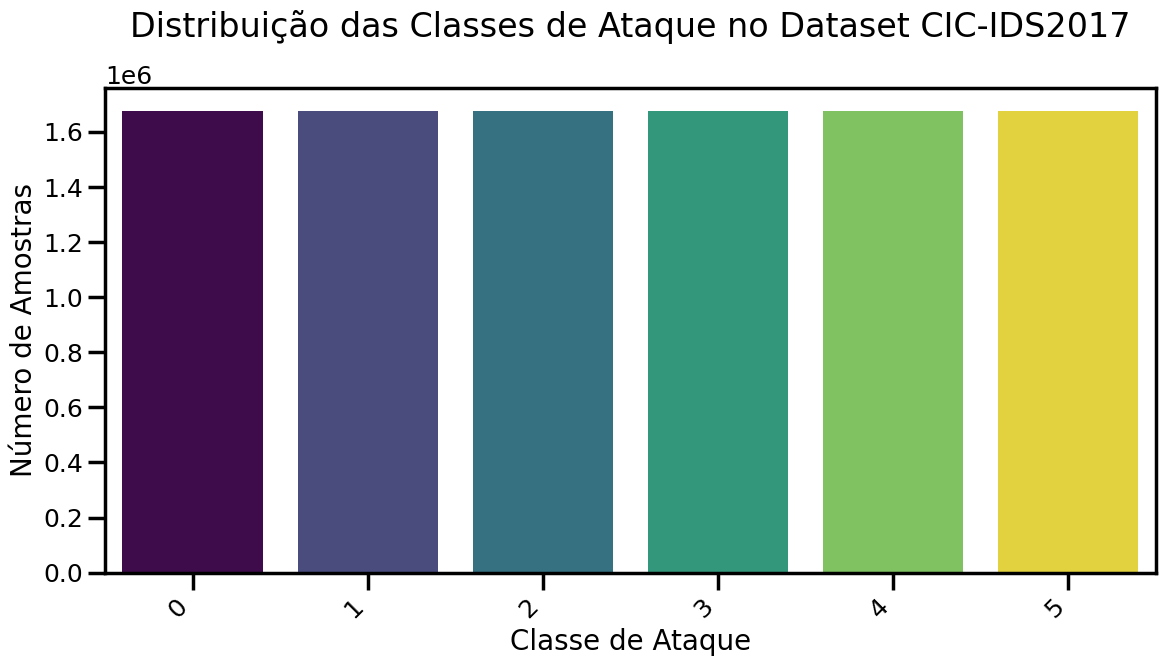

In [33]:
print("Distribuição das Classes de Ataque:")

label_counts = pd.Series(y_train_res).value_counts()

plt.figure(figsize=(12, 7))
sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, legend=False, palette='viridis')
plt.title('Distribuição das Classes de Ataque no Dataset CIC-IDS2017')
plt.xlabel('Classe de Ataque')
plt.ylabel('Número de Amostras')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('imagens_artigo/distribuicao_classes_ataque(apos_balanceamento_smote).pdf', dpi=300, bbox_inches='tight')
plt.show()

## Configuração do Dicionário de Modelo
Dicionário contendo todos os classificadores que serão comparados.
 A chave é o nome do modelo (para os gráficos/tabelas) e o valor é a instância do algoritmo.

In [34]:
modelos = {
    # modelos baseados em arvore com 'n_jobs=-1' para paralelismo full
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        verbose=-1  # pausa avisos que não quebrem o treinamento
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        thread_count=-1,  # usa 'thread_count' em vez de 'n_jobs'
        verbose=0         # pausa o log de treinamento detalhado
    ),

    "Naive Bayes": GaussianNB(),

    "SVM (LinearSVC)": LinearSVC(
        random_state=42,
        max_iter=10000,
        dual='auto'      # para novas versões
    )
}

print(f"Dicionário de modelos criado com sucesso! Total de modelos configurados: {len(modelos)}")

Dicionário de modelos criado com sucesso! Total de modelos configurados: 6


## Loop de Treinamento e Avaliação dos modelos


In [35]:
# lista para armazenar os resultados de cada modelo
resultados_comparativos = []

print(f"Iniciando pipeline de treinamento e avaliação para {len(modelos)} modelos\n")
print("-" * 80)

# loop principal
for nome, modelo in modelos.items():
    print(f"Processando: {nome}")

    # 1° Treinamento (com medição de tempo)
    start_train = time.time()
    modelo.fit(X_train_res, y_train_res) # treina com dados balanceados pelo SMOTE
    end_train = time.time()
    tempo_treino = end_train - start_train

    # 2° Inferência (com medição de tempo)
    start_pred = time.time()
    y_pred = modelo.predict(X_test_selecionado) # dados de teste originais
    end_pred = time.time()
    tempo_inferencia = end_pred - start_pred

    # 3° Cálculo das Métricas
    # average='weighted' serve para lidar com o desbalanceamento natural do teste
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # salva todos os resultados individuais
    resultados_comparativos.append({
        "Modelo": nome,
        "Acurácia": acc,
        "F1-Score": f1,
        "Precisão": prec,
        "Recall": rec,
        "Tempo Treino (s)": tempo_treino,
        "Tempo Inferência (s)": tempo_inferencia
    }) 

    print(f"Concluído. Acurácia: {acc:.4f} | F1: {f1:.4f} | Treino: {tempo_treino:.2f}s")
    print("-" * 80)

Iniciando pipeline de treinamento e avaliação para 6 modelos

--------------------------------------------------------------------------------
Processando: Random Forest
Concluído. Acurácia: 0.9965 | F1: 0.9969 | Treino: 1437.96s
--------------------------------------------------------------------------------
Processando: XGBoost
Concluído. Acurácia: 0.9920 | F1: 0.9942 | Treino: 351.70s
--------------------------------------------------------------------------------
Processando: LightGBM


c:\Users\JHONATAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Concluído. Acurácia: 0.9922 | F1: 0.9942 | Treino: 222.74s
--------------------------------------------------------------------------------
Processando: CatBoost
Concluído. Acurácia: 0.9912 | F1: 0.9934 | Treino: 5668.79s
--------------------------------------------------------------------------------
Processando: Naive Bayes
Concluído. Acurácia: 0.5727 | F1: 0.6837 | Treino: 10.98s
--------------------------------------------------------------------------------
Processando: SVM (LinearSVC)
Concluído. Acurácia: 0.7085 | F1: 0.7943 | Treino: 3416.71s
--------------------------------------------------------------------------------


In [36]:
# benchmark para tempos de inferência

dados_inferencia = []

# quantidades de amostras
cenarios = [1, 100, 1000, "Todos"]

print(f"Iniciando Benchmark de Tempo de Inferência para {len(modelos)} modelos...")
print("-" * 80)

for nome_modelo, modelo in modelos.items():
    print(f"Avaliando latência: {nome_modelo}")
    
    for cenario in cenarios:
        if cenario == "Todos":
            X_batch = X_test_selecionado
            qtd_amostras = len(X_test_selecionado)
            label_cenario = "Total"
        else:
            qtd_amostras = min(cenario, len(X_test_selecionado))
            X_batch = X_test_selecionado[:qtd_amostras]
            label_cenario = str(qtd_amostras)

        inicio = time.perf_counter()
        _ = modelo.predict(X_batch) 
        fim = time.perf_counter()
        
        tempo_total = fim - inicio
        
        tempo_por_amostra = tempo_total / qtd_amostras if qtd_amostras > 0 else 0

        dados_inferencia.append({
            "Modelo": nome_modelo,
            "Cenário (Amostras)": label_cenario,
            "Qtd Real": qtd_amostras,
            "Tempo Total (s)": tempo_total,
            "Tempo por Amostra (s)": tempo_por_amostra
        })

print("-" * 80)
print("Benchmark concluído.")

df_inferencia = pd.DataFrame(dados_inferencia)

display(df_inferencia.head(24))

Iniciando Benchmark de Tempo de Inferência para 6 modelos...
--------------------------------------------------------------------------------
Avaliando latência: Random Forest
Avaliando latência: XGBoost
Avaliando latência: LightGBM


c:\Users\JHONATAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\JHONATAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\JHONATAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\JHONATAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Avaliando latência: CatBoost
Avaliando latência: Naive Bayes
Avaliando latência: SVM (LinearSVC)
--------------------------------------------------------------------------------
Benchmark concluído.


,Modelo,Cenário (Amostras),Qtd Real,Tempo Total (s),Tempo por Amostra (s)
0,Random Forest,1,1,0.487195,4.871952e-01
1,Random Forest,100,100,0.073545,7.354490e-04
2,Random Forest,1000,1000,0.072424,7.242450e-05
3,Random Forest,Total,504160,1.559411,3.093087e-06
4,XGBoost,1,1,0.022892,2.289160e-02
5,XGBoost,100,100,0.002185,2.184900e-05
6,XGBoost,1000,1000,0.003417,3.417300e-06
7,XGBoost,Total,504160,0.744472,1.476659e-06
8,LightGBM,1,1,0.017202,1.720180e-02
9,LightGBM,100,100,0.002591,2.591000e-05


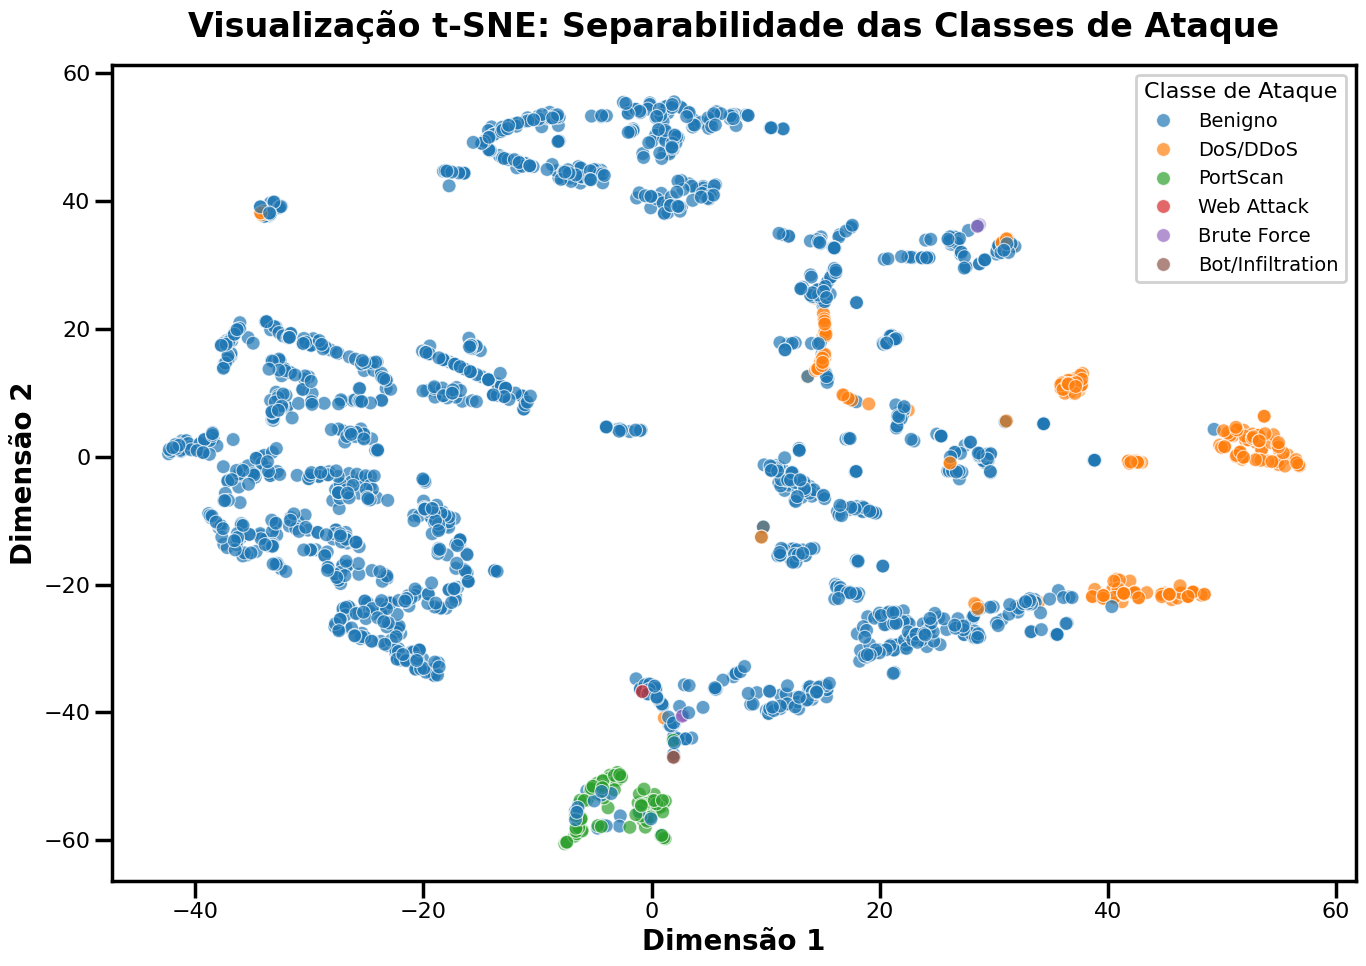

In [37]:

X_vis = X_test_selecionado[:2000]
y_vis = y_test[:2000]

# decodificar rótulos para a legenda ficar bonita
y_vis_labels = label_encoder.inverse_transform(y_vis)

tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X_vis)

plt.figure(figsize=(14, 10))
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y_vis_labels, palette='tab10', alpha=0.7, s=100)
plt.title("Visualização t-SNE: Separabilidade das Classes de Ataque", fontsize=24, fontweight='bold', pad=20)
plt.xlabel("Dimensão 1", fontsize=20, fontweight='bold')
plt.ylabel("Dimensão 2", fontsize=20, fontweight='bold')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=14, title='Classe de Ataque', title_fontsize=16, loc='best', framealpha=0.9)
plt.tight_layout()
plt.savefig('imagens_artigo/visualizacao_tsne_separabilidade_classes_ataque.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Consolidação dos Resultados


### cria um DataFrame pandas para facilitar a visualização e criação de tabelas no artigo


In [38]:
df_resultados = pd.DataFrame(resultados_comparativos)

### Ordena do melhor F1-Score para o pior


In [39]:
df_resultados = df_resultados.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

### Exibe a tabela formatada

In [40]:
print("\nTabela Final de Comparação")
display(df_resultados)


Tabela Final de Comparação


,Modelo,Acurácia,F1-Score,Precisão,Recall,Tempo Treino (s),Tempo Inferência (s)
0,Random Forest,0.996495,0.996855,0.997420,0.996495,1437.959637,2.229047
1,LightGBM,0.992211,0.994237,0.996918,0.992211,222.740904,2.718997
2,XGBoost,0.992003,0.994162,0.997007,0.992003,351.700327,1.429036
3,CatBoost,0.991241,0.993390,0.996385,0.991241,5668.790655,0.650723
4,SVM (LinearSVC),0.708521,0.794280,0.949864,0.708521,3416.714381,0.281840
5,Naive Bayes,0.572749,0.683694,0.916081,0.572749,10.976918,0.789922


Gerando Curva de Aprendizado para o campeão: Random Forest


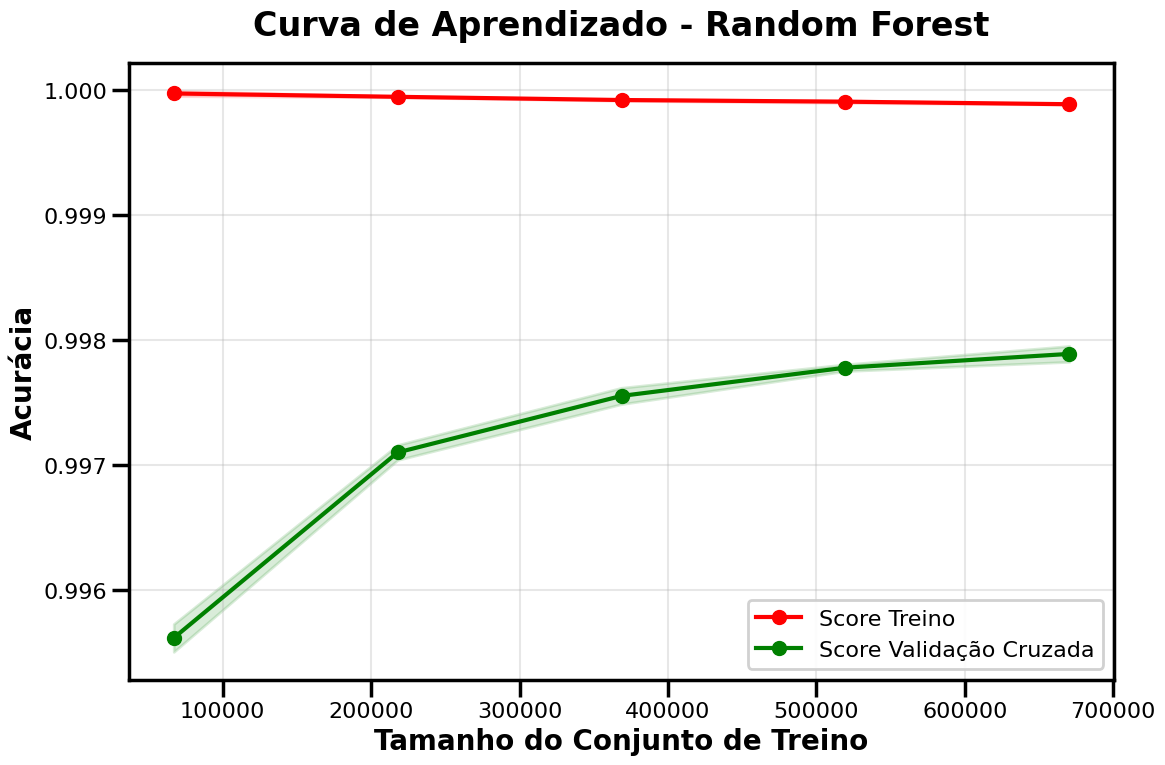

In [41]:
nome_campeao = df_resultados.iloc[0]["Modelo"]
modelo_campeao = modelos[nome_campeao]

print(f"Gerando Curva de Aprendizado para o campeão: {nome_campeao}")
# print("(Usando amostra de 10% do treino para rapidez)")

if isinstance(X_train_res, pd.DataFrame):
    X_lc = X_train_res.sample(frac=0.1, random_state=42)
    y_lc = y_train_res.sample(frac=0.1, random_state=42)
else:
    indices = np.random.choice(len(X_train_res), int(len(X_train_res)*0.1), replace=False)
    X_lc = X_train_res[indices]
    y_lc = y_train_res[indices]

train_sizes, train_scores, test_scores = learning_curve(
    modelo_campeao, 
    X_lc, 
    y_lc, 
    cv=3, 
    n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(12, 8))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Score Treino", linewidth=3, markersize=10)
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Score Validação Cruzada", linewidth=3, markersize=10)

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color="g")

plt.title(f"Curva de Aprendizado - {nome_campeao}", fontsize=24, fontweight='bold', pad=20)
plt.xlabel("Tamanho do Conjunto de Treino", fontsize=20, fontweight='bold')
plt.ylabel("Acurácia", fontsize=20, fontweight='bold')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(loc="best", fontsize=16, framealpha=0.9)
plt.grid(alpha=0.3, linewidth=1.5)
plt.tight_layout()
plt.savefig(f'imagens_artigo/curva_de_aprendizado_{nome_campeao}.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Validação Cruzada (K-Fold Cross-Validation)

In [42]:


# configuração da Validação Cruzada
# 5 dobras (folds)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Resultados da Validação Cruzada (5-Folds)\n")
print(f"{'Modelo':<20} | {'Acurácia Média':<15} | {'Desvio Padrão':<15}")
print("-" * 56)

results_cv = []


if isinstance(X_train_res, np.ndarray):
    X_temp = pd.DataFrame(X_train_res)
    y_temp = pd.Series(y_train_res)
else:
    X_temp = X_train_res
    y_temp = y_train_res

tamanho_amostra = int(len(X_temp) * 0.1) # 10% dos dados
indices_aleatorios = np.random.choice(len(X_temp), tamanho_amostra, replace=False)

X_cv_sample = X_temp.iloc[indices_aleatorios]
y_cv_sample = y_temp.iloc[indices_aleatorios]

# loop de Validação
for nome, modelo in modelos.items():
    # scoring='accuracy' ou 'f1_weighted'
    scores = cross_val_score(modelo, X_cv_sample, y_cv_sample, cv=kfold, scoring='accuracy', n_jobs=-1)
    
    mean_acc = scores.mean()
    std_acc = scores.std()
    
    results_cv.append({"Modelo": nome, "Média": mean_acc, "Std": std_acc})
    
    # formatação para o output
    print(f"{nome:<20} | {mean_acc:.4f}          | ±{std_acc:.4f}")

Resultados da Validação Cruzada (5-Folds)

Modelo               | Acurácia Média  | Desvio Padrão  
--------------------------------------------------------
Random Forest        | 0.9981          | ±0.0001
XGBoost              | 0.9977          | ±0.0001
LightGBM             | 0.9932          | ±0.0043
CatBoost             | 0.9970          | ±0.0001
Naive Bayes          | 0.8367          | ±0.0006
SVM (LinearSVC)      | 0.9180          | ±0.0007


## Matriz de Confusão Normalizada

Gerando Matriz de Confusão Normalizada para: Random Forest


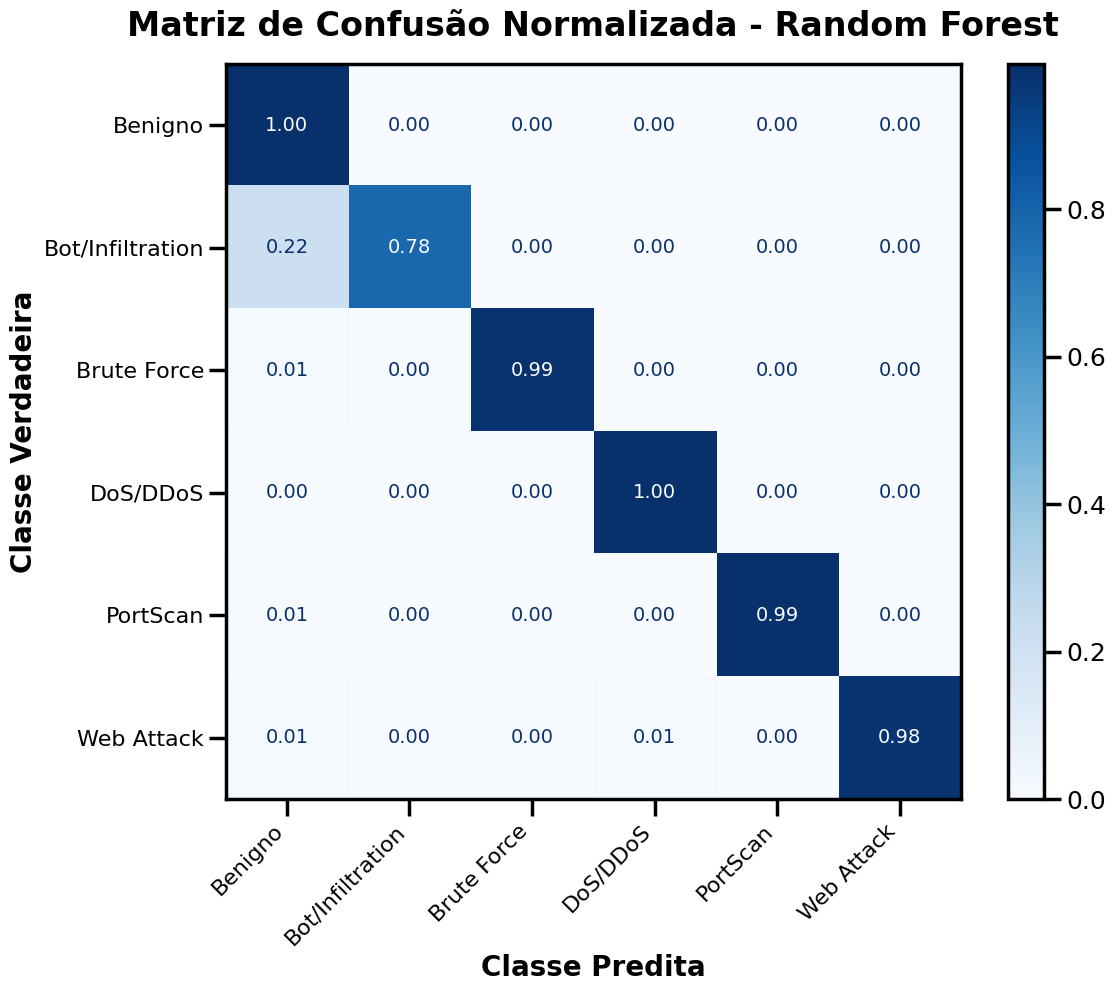

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
modelo_campeao_nome = df_resultados.iloc[0]["Modelo"]
modelo_campeao = modelos[modelo_campeao_nome]

print(f"Gerando Matriz de Confusão Normalizada para: {modelo_campeao_nome}")

y_pred_campeao = modelo_campeao.predict(X_test_selecionado)

# matriz normalizada 
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_campeao, 
    normalize='true', 
    display_labels=label_encoder.classes_,
    cmap='Blues',
    values_format=".2f",
    ax=ax
)
plt.xticks(rotation=45, ha='right', fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Classe Predita', fontsize=20, fontweight='bold')
plt.ylabel('Classe Verdadeira', fontsize=20, fontweight='bold')
plt.title(f"Matriz de Confusão Normalizada - {modelo_campeao_nome}", fontsize=24, fontweight='bold', pad=20)

# Aumentar o tamanho da fonte dos valores na matriz
for text in ax.texts:
    text.set_fontsize(14)

plt.tight_layout()
plt.savefig(f'imagens_artigo/matriz_confusao_normalizada_{modelo_campeao_nome}.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Gráfico de Radar (Spider Chart)

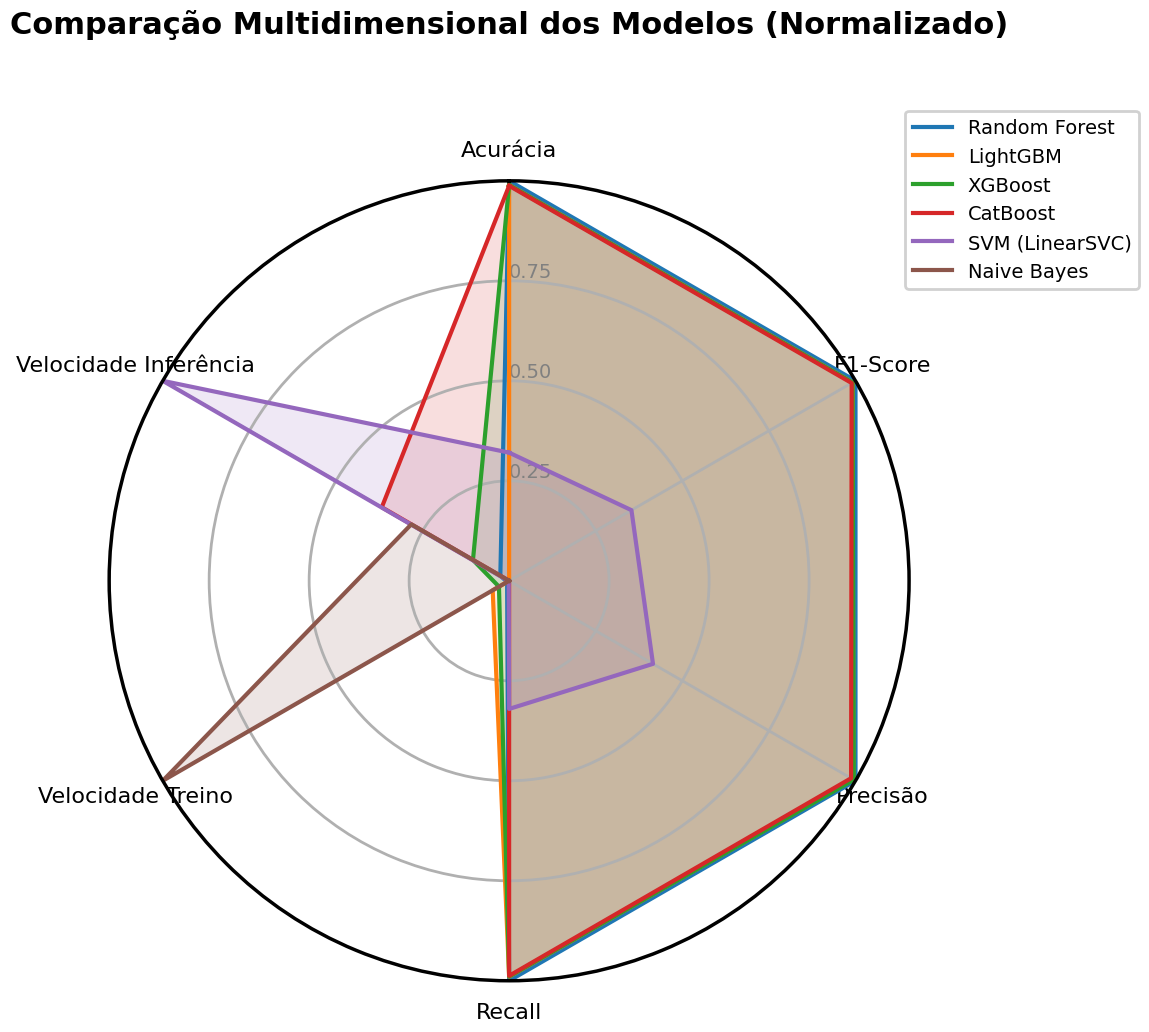

In [44]:
from sklearn.preprocessing import MinMaxScaler

# preparar os dados
df_radar = df_resultados.copy()

# converter tempos (Transformar em "Velocidade")
# quanto menor o tempo, maior a pontuação (1 / tempo) para mostrar no radar
df_radar["Velocidade Treino"] = 1 / (df_radar["Tempo Treino (s)"] + 1e-5)
df_radar["Velocidade Inferência"] = 1 / (df_radar["Tempo Inferência (s)"] + 1e-5)

# selecionar métricas para o radar
metrics = ["Acurácia", "F1-Score", "Precisão", "Recall", "Velocidade Treino", "Velocidade Inferência"]

# normalizar tudo para escala 0-1 para o gráfico ficar bonito
scaler = MinMaxScaler()
df_radar[metrics] = scaler.fit_transform(df_radar[metrics])

# função para plotar Radar
from math import pi

def plot_radar(df, metrics, title):
    categories = metrics
    N = len(categories)
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    plt.figure(figsize=(12, 12))
    ax = plt.subplot(111, polar=True)
    
    # primeiro eixo no topo
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    
    plt.xticks(angles[:-1], categories, fontsize=16)
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75], ["0.25", "0.50", "0.75"], color="grey", fontsize=14)
    plt.ylim(0, 1)
    
    # plotar cada modelo
    for index, row in df.iterrows():
        values = row[metrics].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=3, label=row["Modelo"])
        ax.fill(angles, values, alpha=0.15)
        
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=14, framealpha=0.9)
    plt.title(title, y=1.15, fontsize=22, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('imagens_artigo/radar_comparacao_modelos.pdf', dpi=300, bbox_inches='tight')
    plt.show()

plot_radar(df_radar, metrics, "Comparação Multidimensional dos Modelos (Normalizado)")

## Curvas ROC e AUC (Multiclasse)

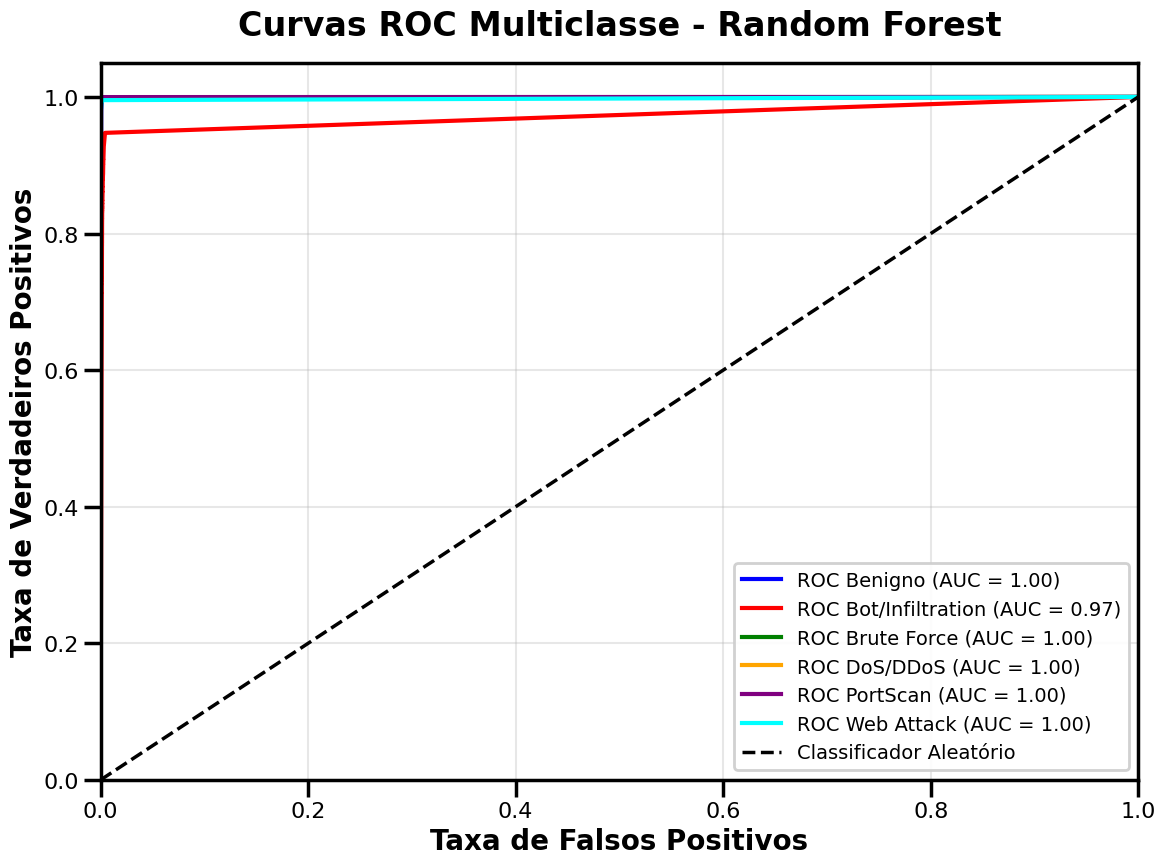

In [45]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# preparar dados binarizados
classes = label_encoder.classes_
n_classes = len(classes)

# binarizar y_test e previsões
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# pegar probabilidades (necessário para ROC)

if hasattr(modelo_campeao, "predict_proba"):
    y_score = modelo_campeao.predict_proba(X_test_selecionado)
else:
    y_score = modelo_campeao.decision_function(X_test_selecionado)

# calcular FPR, TPR e AUC para cada classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# plotar todas as curvas ROC
plt.figure(figsize=(12, 9))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=3,
             label=f'ROC {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2.5, label='Classificador Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos', fontsize=20, fontweight='bold')
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=20, fontweight='bold')
plt.title(f'Curvas ROC Multiclasse - {modelo_campeao_nome}', fontsize=24, fontweight='bold', pad=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(loc="lower right", fontsize=14, framealpha=0.9)
plt.grid(True, alpha=0.3, linewidth=1.5)
plt.tight_layout()
plt.savefig(f'imagens_artigo/curvas_roc_multiclasse_{modelo_campeao_nome}.pdf', dpi=300, bbox_inches='tight')
plt.show()

Gerando Curva Precision-Recall.


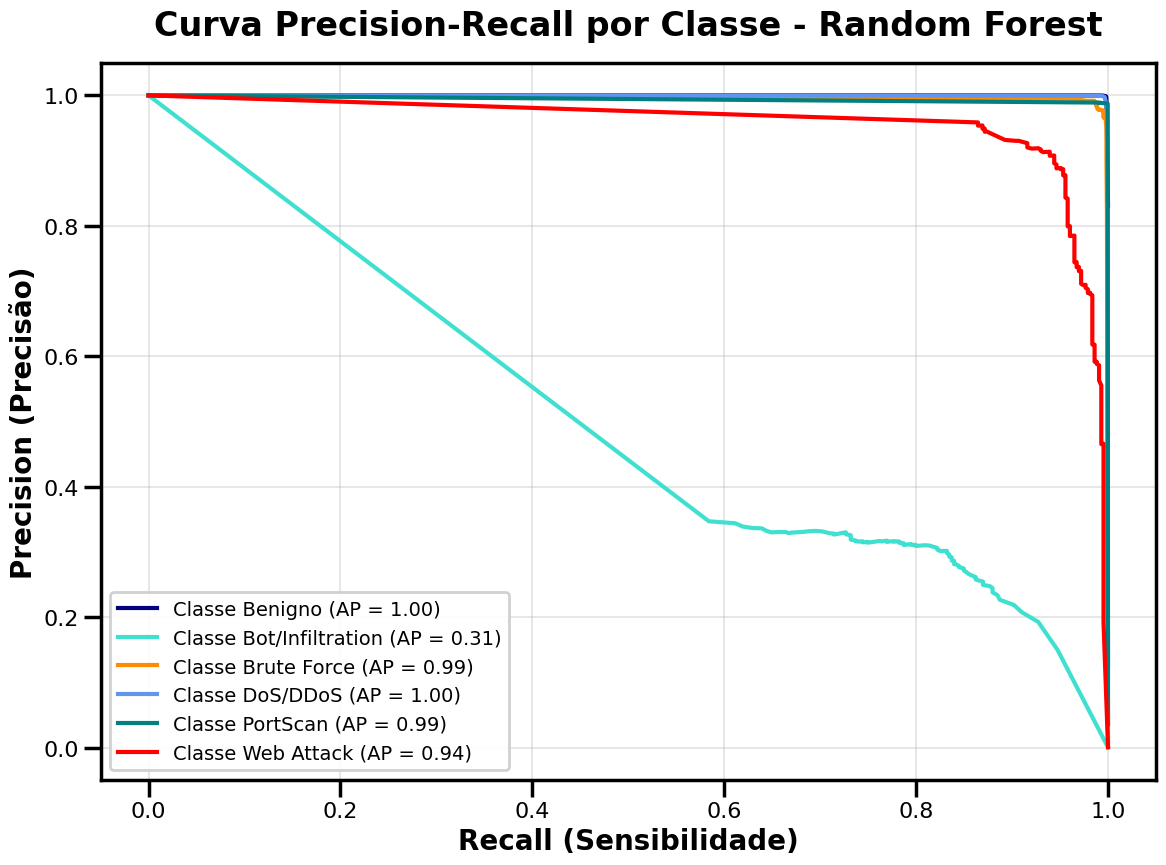

In [46]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

print("Gerando Curva Precision-Recall.")

classes = label_encoder.classes_
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

try:
    y_score = modelo_campeao.predict_proba(X_test_selecionado)
except:
    y_score = modelo_campeao.decision_function(X_test_selecionado)

precision = dict()
recall = dict()
average_precision = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_score[:, i])

plt.figure(figsize=(12, 9))
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal', 'red', 'purple'])

for i, color in zip(range(n_classes), colors):
    plt.plot(recall[i], precision[i], color=color, lw=3,
             label='Classe {0} (AP = {1:0.2f})'.format(classes[i], average_precision[i]))

plt.xlabel('Recall (Sensibilidade)', fontsize=20, fontweight='bold')
plt.ylabel('Precision (Precisão)', fontsize=20, fontweight='bold')
plt.title(f'Curva Precision-Recall por Classe - {nome_campeao}', fontsize=24, fontweight='bold', pad=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(loc="lower left", fontsize=14, framealpha=0.9)
plt.grid(alpha=0.3, linewidth=1.5)
plt.tight_layout()
plt.savefig(f'imagens_artigo/curva_precision_recall_{nome_campeao}.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Gráfico de Tempos (Logarítmico)


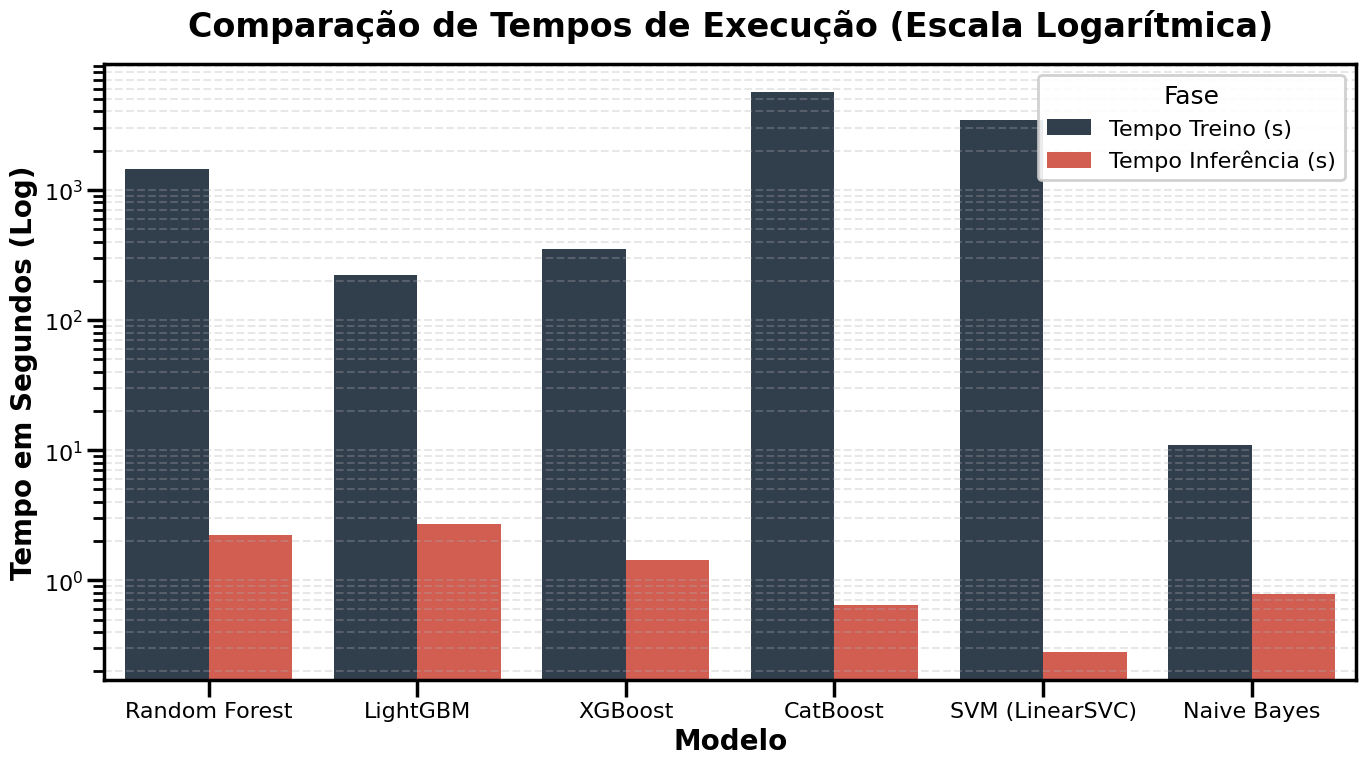

In [47]:
df_time = df_resultados.melt(
    id_vars="Modelo", 
    value_vars=["Tempo Treino (s)", "Tempo Inferência (s)"],
    var_name="Etapa", 
    value_name="Tempo (s)"
)

plt.figure(figsize=(14, 8))
sns.barplot(data=df_time, x="Modelo", y="Tempo (s)", hue="Etapa", palette=["#2c3e50", "#e74c3c"])

# escala Logarítmica do tempo de execução
plt.yscale("log")

plt.title("Comparação de Tempos de Execução (Escala Logarítmica)", fontsize=24, fontweight='bold', pad=20)
plt.ylabel("Tempo em Segundos (Log)", fontsize=20, fontweight='bold')
plt.xlabel("Modelo", fontsize=20, fontweight='bold')
plt.xticks(fontsize=16, rotation=0)
plt.yticks(fontsize=16)
plt.grid(True, which="both", axis="y", linestyle="--", alpha=0.3, linewidth=1.5)
plt.legend(title="Fase", fontsize=16, title_fontsize=18, framealpha=0.9)
plt.tight_layout()
plt.savefig('imagens_artigo/comparacao_tempos_execucao_modelos.pdf', dpi=300, bbox_inches='tight')
plt.show()

## EXPLICABILIDADE (XAI) ROBUSTA COM SHAP

Modelo Campeão selecionado para XAI: Random Forest
Calculando valores SHAP para 2000 amostras


ℹ Modelo Multiclasse (Array) detectado. Focando no índice 1.

[1] SHAP Summary Plot (Beeswarm) - Visão Global


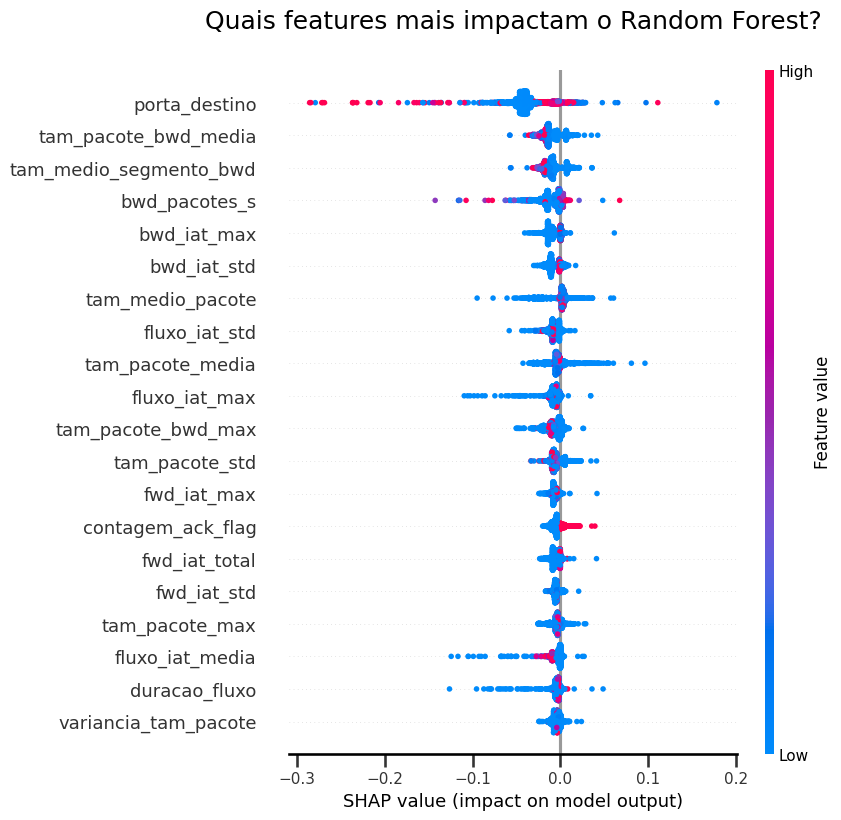


[2] Caçando Casos Específicos para Análise Local

Análise de Caso: Falso Positivo (Alarme Falso) (Amostra #47)
Real: Benigno | Previsto: Web Attack


c:\Users\JHONATAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


<Figure size 2000x400 with 0 Axes>

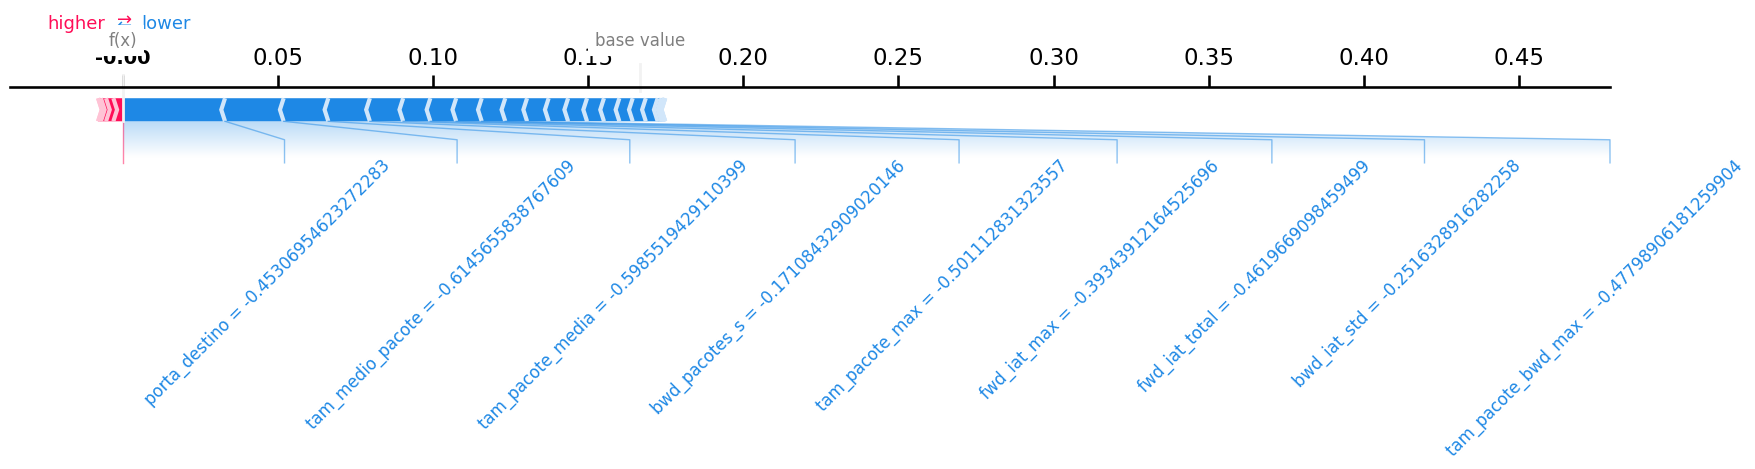

In [48]:
sns.set_context("talk")
plt.rcParams.update({
    'font.size': 12,        
    'axes.titlesize': 16,
    'figure.figsize': (14, 10) 
})

nome_campeao = df_resultados.iloc[0]["Modelo"]
modelo_campeao = modelos[nome_campeao]
print(f"Modelo Campeão selecionado para XAI: {nome_campeao}")

X_test_df = pd.DataFrame(X_test_selecionado, columns=nomes_features_selecionadass)
y_test_series = pd.Series(y_test)

TAMANHO_AMOSTRA_XAI = 2000
indices_amostra = y_test_series.sample(TAMANHO_AMOSTRA_XAI, random_state=42).index

X_sample = X_test_df.loc[indices_amostra] 
y_sample = y_test_series.loc[indices_amostra] 

print(f"Calculando valores SHAP para {TAMANHO_AMOSTRA_XAI} amostras")
shap.initjs() 

try:
    if nome_campeao in ["Random Forest", "XGBoost", "LightGBM", "CatBoost"]:
        explainer = shap.TreeExplainer(modelo_campeao)
        shap_values = explainer.shap_values(X_sample, check_additivity=False)
    else:
        print("Usando KernelExplainer (Lento).")
        explainer = shap.KernelExplainer(modelo_campeao.predict, X_train_res.sample(50, random_state=42))
        shap_values = explainer.shap_values(X_sample)

    if isinstance(shap_values, list):
        print("ℹ Modelo Multiclasse (Lista) detectado. Focando no índice 1.")
        shap_values_plot = shap_values[1]
        expected_value_plot = explainer.expected_value[1]
    else:
        if len(shap_values.shape) == 3:
             print("ℹ Modelo Multiclasse (Array) detectado. Focando no índice 1.")
             shap_values_plot = shap_values[:, :, 1] 
             expected_value_plot = explainer.expected_value[1]
        else:
            shap_values_plot = shap_values
            expected_value_plot = explainer.expected_value

    
    print("\n[1] SHAP Summary Plot (Beeswarm) - Visão Global")
    
    fig = plt.figure(figsize=(12, 10)) 
    
    shap.summary_plot(shap_values_plot, X_sample, show=False)
    
    plt.title(f"Quais features mais impactam o {nome_campeao}?", fontsize=18, pad=30)
    
    
    plt.subplots_adjust(bottom=0.2, top=0.92, left=0.2, right=0.9)
    
    plt.savefig('imagens_artigo/shap_beeswarm.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    

    print("\n[2] Caçando Casos Específicos para Análise Local")
    
    y_pred_sample = modelo_campeao.predict(X_sample)
    
    try:
        idx_benigno = label_encoder.transform(['Benigno'])[0]
    except:
        idx_benigno = 0

    fp_indices = [i for i, (pred, real) in enumerate(zip(y_pred_sample, y_sample)) 
                  if pred != idx_benigno and real == idx_benigno]

    tp_indices = [i for i, (pred, real) in enumerate(zip(y_pred_sample, y_sample)) 
                  if pred != idx_benigno and real == pred]

    def plotar_caso(index_na_amostra, tipo_caso):
        print(f"\nAnálise de Caso: {tipo_caso} (Amostra #{index_na_amostra})")
        try:
            try:
                classe_real = label_encoder.inverse_transform([y_sample.iloc[index_na_amostra]])[0]
                classe_pred = label_encoder.inverse_transform([y_pred_sample[index_na_amostra]])[0]
            except:
                classe_real = y_sample.iloc[index_na_amostra]
                classe_pred = y_pred_sample[index_na_amostra]
                
            print(f"Real: {classe_real} | Previsto: {classe_pred}")
            
            plt.figure(figsize=(20, 4)) 
            
            shap.force_plot(
                expected_value_plot, 
                shap_values_plot[index_na_amostra,:], 
                X_sample.iloc[index_na_amostra,:], 
                matplotlib=True,
                show=False,
                text_rotation=45 
            )
           
            plt.subplots_adjust(bottom=0.3, top=0.8, right=0.9, left=0.1)
            
            plt.savefig(f'imagens_artigo/shap_force_{tipo_caso.split()[0]}.pdf', dpi=300, bbox_inches='tight')
            plt.show()
            
        except Exception as e:
            print(f"Não foi possível gerar o gráfico para este caso: {e}")

    if fp_indices:
        plotar_caso(fp_indices[0], "Falso Positivo (Alarme Falso)")
    elif tp_indices:
        plotar_caso(tp_indices[0], "Verdadeiro Positivo (Ataque Detectado)")
    else:
        print("\nNenhum caso de interesse encontrado na amostra.")

except Exception as e:
    print(f"Erro na análise XAI: {e}")
    # traceback.print_exc()

Modelo Campeão selecionado para XAI: Random Forest
Calculando valores SHAP para 2000 amostras


ℹ Modelo Multiclasse (Array) detectado. Focando no índice 1.

[1] SHAP Summary Plot (Beeswarm) - Visão Global


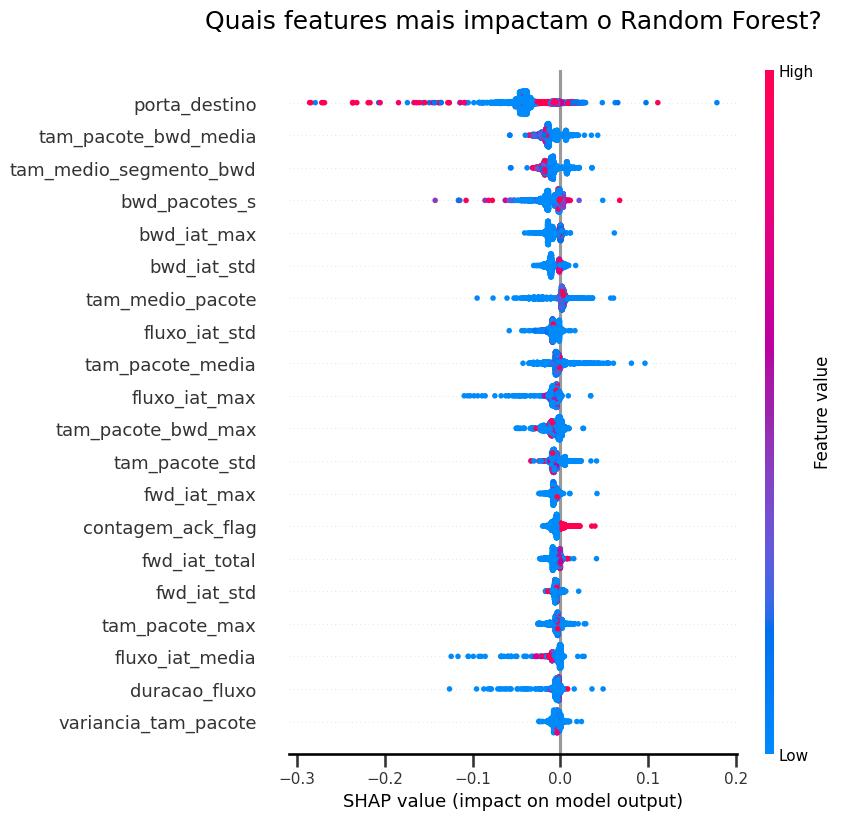


[2] Caçando Casos Específicos para Análise Local

Análise de Caso: Falso Positivo (Alarme Falso) (Amostra #47)
Real: Benigno | Previsto: Web Attack


c:\Users\JHONATAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


<Figure size 2000x400 with 0 Axes>

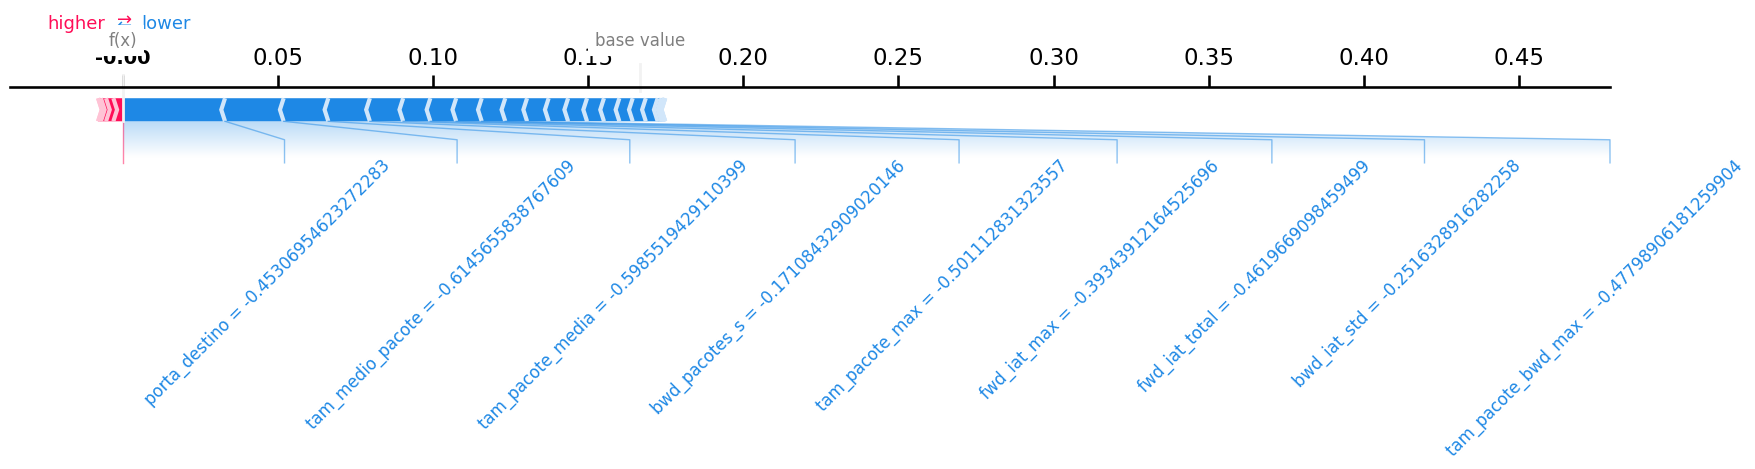

In [49]:
sns.set_context("talk")
plt.rcParams.update({
    'font.size': 12,        
    'axes.titlesize': 16,
    'figure.figsize': (14, 10) 
})

nome_campeao = df_resultados.iloc[0]["Modelo"]
modelo_campeao = modelos[nome_campeao]
print(f"Modelo Campeão selecionado para XAI: {nome_campeao}")

X_test_df = pd.DataFrame(X_test_selecionado, columns=nomes_features_selecionadass)
y_test_series = pd.Series(y_test)

TAMANHO_AMOSTRA_XAI = 2000
indices_amostra = y_test_series.sample(TAMANHO_AMOSTRA_XAI, random_state=42).index

X_sample = X_test_df.loc[indices_amostra] 
y_sample = y_test_series.loc[indices_amostra] 

print(f"Calculando valores SHAP para {TAMANHO_AMOSTRA_XAI} amostras")
shap.initjs() 

try:
    if nome_campeao in ["Random Forest", "XGBoost", "LightGBM", "CatBoost"]:
        explainer = shap.TreeExplainer(modelo_campeao)
        shap_values = explainer.shap_values(X_sample, check_additivity=False)
    else:
        print("Usando KernelExplainer (Lento).")
        explainer = shap.KernelExplainer(modelo_campeao.predict, X_train_res.sample(50, random_state=42))
        shap_values = explainer.shap_values(X_sample)

    if isinstance(shap_values, list):
        print("ℹ Modelo Multiclasse (Lista) detectado. Focando no índice 1.")
        shap_values_plot = shap_values[1]
        expected_value_plot = explainer.expected_value[1]
    else:
        if len(shap_values.shape) == 3:
             print("ℹ Modelo Multiclasse (Array) detectado. Focando no índice 1.")
             shap_values_plot = shap_values[:, :, 1] 
             expected_value_plot = explainer.expected_value[1]
        else:
            shap_values_plot = shap_values
            expected_value_plot = explainer.expected_value

    
    print("\n[1] SHAP Summary Plot (Beeswarm) - Visão Global")
    
    fig = plt.figure(figsize=(12, 10)) 
    
    shap.summary_plot(shap_values_plot, X_sample, show=False)
    
    plt.title(f"Quais features mais impactam o {nome_campeao}?", fontsize=18, pad=30)
    
    
    plt.subplots_adjust(bottom=0.2, top=0.92, left=0.2, right=0.9)
    
    plt.savefig('imagens_artigo/shap_beeswarm.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    

    print("\n[2] Caçando Casos Específicos para Análise Local")
    
    y_pred_sample = modelo_campeao.predict(X_sample)
    
    try:
        idx_benigno = label_encoder.transform(['Benigno'])[0]
    except:
        idx_benigno = 0

    fp_indices = [i for i, (pred, real) in enumerate(zip(y_pred_sample, y_sample)) 
                  if pred != idx_benigno and real == idx_benigno]

    tp_indices = [i for i, (pred, real) in enumerate(zip(y_pred_sample, y_sample)) 
                  if pred != idx_benigno and real == pred]

    def plotar_caso(index_na_amostra, tipo_caso):
        print(f"\nAnálise de Caso: {tipo_caso} (Amostra #{index_na_amostra})")
        try:
            try:
                classe_real = label_encoder.inverse_transform([y_sample.iloc[index_na_amostra]])[0]
                classe_pred = label_encoder.inverse_transform([y_pred_sample[index_na_amostra]])[0]
            except:
                classe_real = y_sample.iloc[index_na_amostra]
                classe_pred = y_pred_sample[index_na_amostra]
                
            print(f"Real: {classe_real} | Previsto: {classe_pred}")
            
            plt.figure(figsize=(20, 4)) 
            
            shap.force_plot(
                expected_value_plot, 
                shap_values_plot[index_na_amostra,:], 
                X_sample.iloc[index_na_amostra,:], 
                matplotlib=True,
                show=False,
                text_rotation=45 
            )
           
            plt.subplots_adjust(bottom=0.3, top=0.8, right=0.9, left=0.1)
            
            plt.savefig(f'imagens_artigo/shap_force_{tipo_caso.split()[0]}.pdf', dpi=300, bbox_inches='tight')
            plt.show()
            
        except Exception as e:
            print(f"Não foi possível gerar o gráfico para este caso: {e}")

    if fp_indices:
        plotar_caso(fp_indices[0], "Falso Positivo (Alarme Falso)")
    elif tp_indices:
        plotar_caso(tp_indices[0], "Verdadeiro Positivo (Ataque Detectado)")
    else:
        print("\nNenhum caso de interesse encontrado na amostra.")

except Exception as e:
    print(f"Erro na análise XAI: {e}")
    # traceback.print_exc()

Gerando [1/2] SHAP Dependence Plot...
Feature Principal Identificada: porta_destino


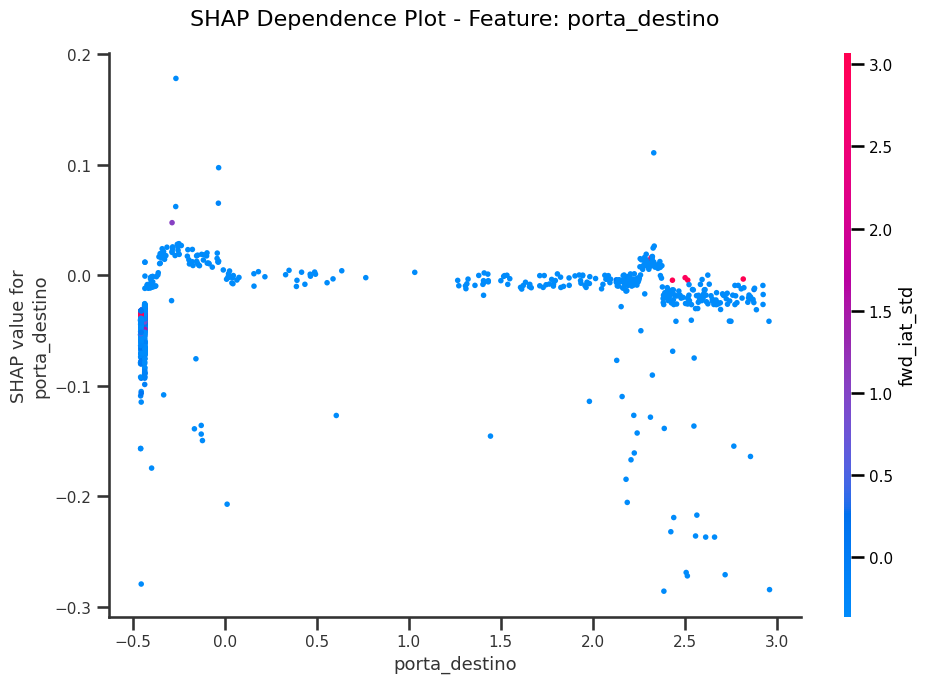


Gerando [2/2] SHAP Force Plot (Amostra Individual)...
Salvo em: imagens_artigo/shap_force_plot.pdf


<Figure size 2000x500 with 0 Axes>

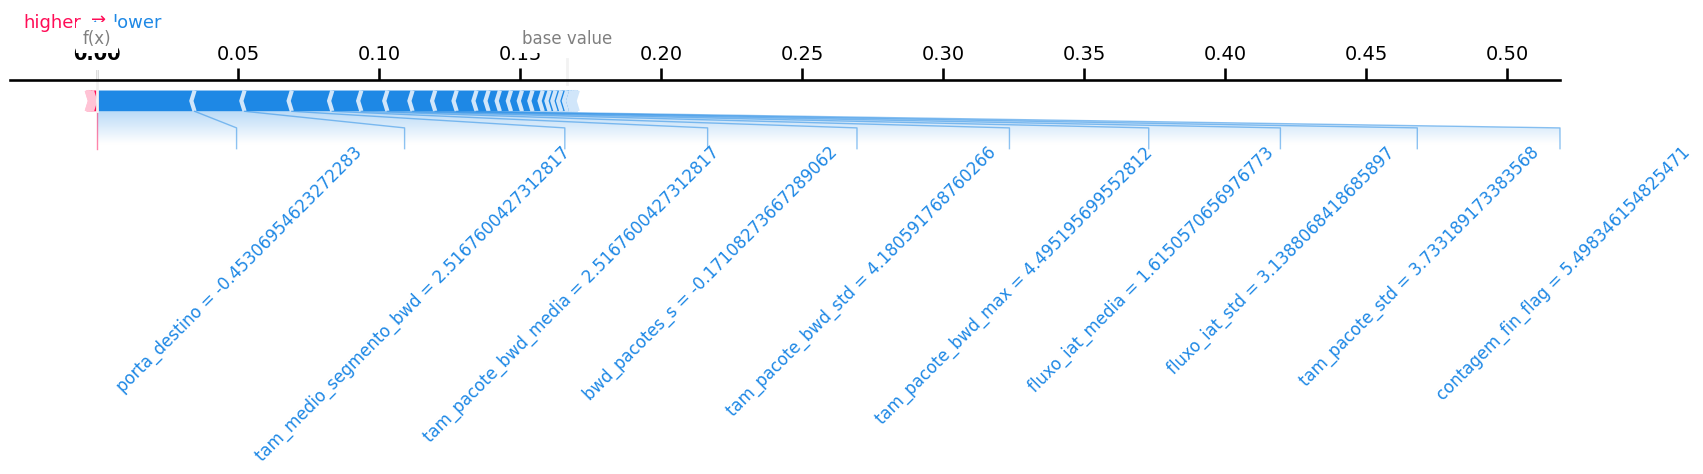

In [50]:
sns.set_context("talk")
plt.rcParams.update({
    'font.size': 12,            
    'axes.titlesize': 16,
    'axes.labelsize': 16,   
    'xtick.labelsize': 14,  
    'ytick.labelsize': 14,  
    'legend.fontsize': 14,  
    'figure.titlesize': 20,
})


print("Gerando [1/2] SHAP Dependence Plot...")

if isinstance(shap_values_plot, list):
    vals = np.abs(shap_values_plot[1]).mean(0) 
else:
    vals = np.abs(shap_values_plot).mean(0) 

feature_importance = pd.DataFrame(list(zip(X_sample.columns, vals)), columns=['col_name','feature_importance_vals'])
feature_importance.sort_values(by=['feature_importance_vals'], ascending=False, inplace=True)
top_feature = feature_importance.iloc[0]['col_name']

print(f"Feature Principal Identificada: {top_feature}")

shap.dependence_plot(
    top_feature, 
    shap_values_plot, 
    X_sample, 
    interaction_index='auto',
    show=False 
)

plt.gcf().set_size_inches(10, 7)
plt.title(f"SHAP Dependence Plot - Feature: {top_feature}", fontsize=16, pad=20)
plt.tight_layout()

plt.savefig('imagens_artigo/shap_dependence_plot.pdf', dpi=300, bbox_inches='tight')
plt.show() 



print("\nGerando [2/2] SHAP Force Plot (Amostra Individual)...")

plt.figure(figsize=(20, 5))

try:
    shap.force_plot(
        expected_value_plot, 
        shap_values_plot[0,:],     
        X_sample.iloc[0,:],         
        matplotlib=True,   
        show=False,             
        text_rotation=45    
    )

    plt.subplots_adjust(top=0.65, bottom=0.2) 

    plt.savefig('imagens_artigo/shap_force_plot.pdf', dpi=300, bbox_inches='tight')
    print("Salvo em: imagens_artigo/shap_force_plot.pdf")
    plt.show()

except Exception as e:
    print(f"Erro ao gerar Force Plot: {e}")

Gerando Curva de Aprendizado para o vice: CatBoost


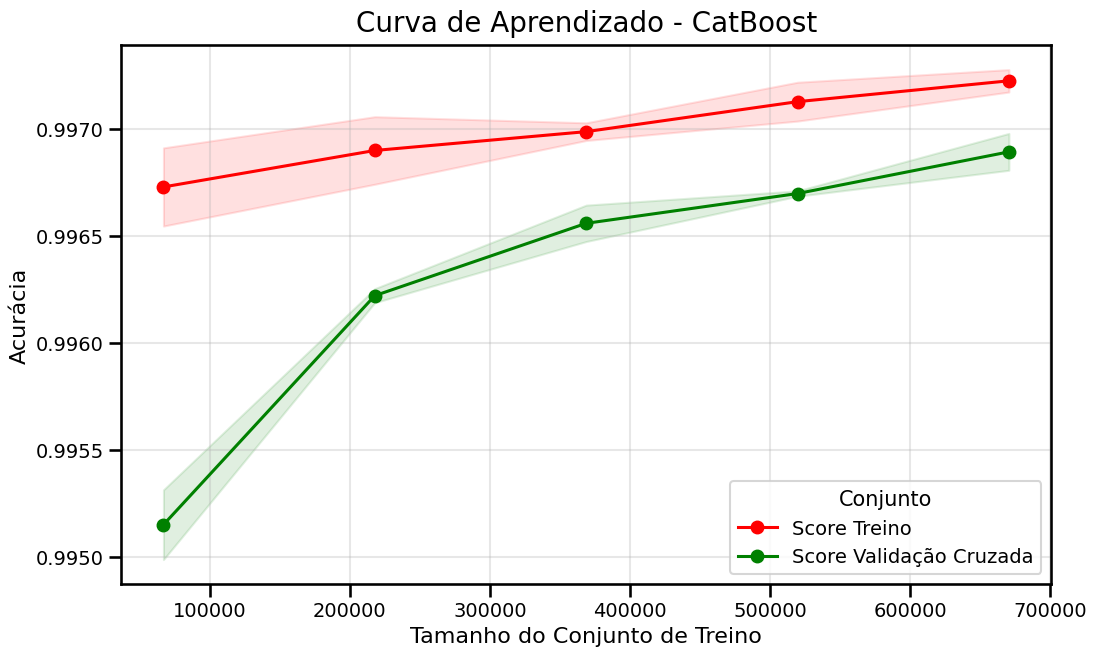

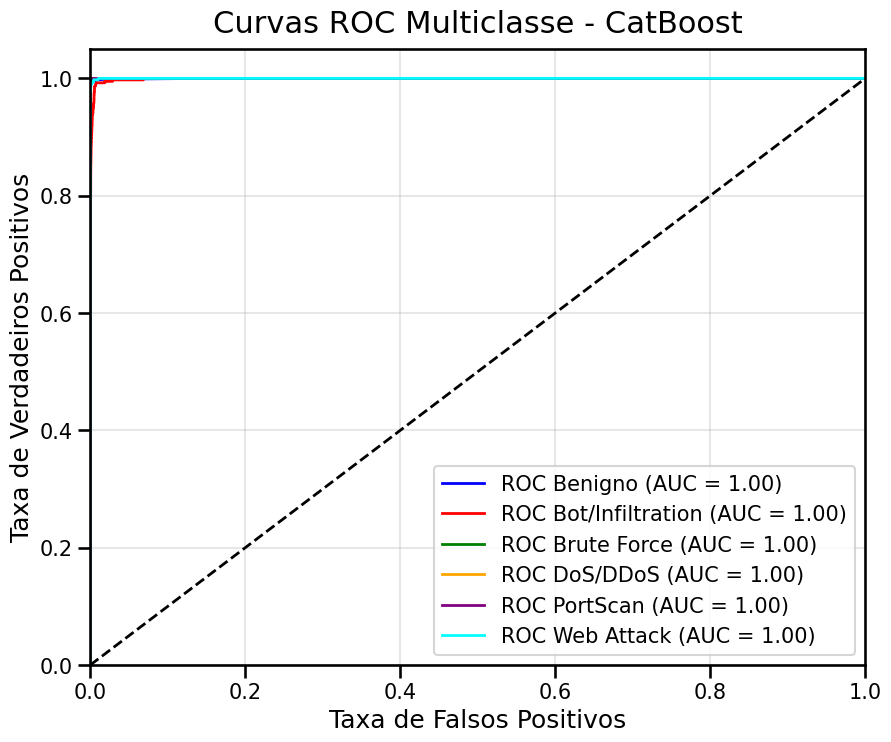

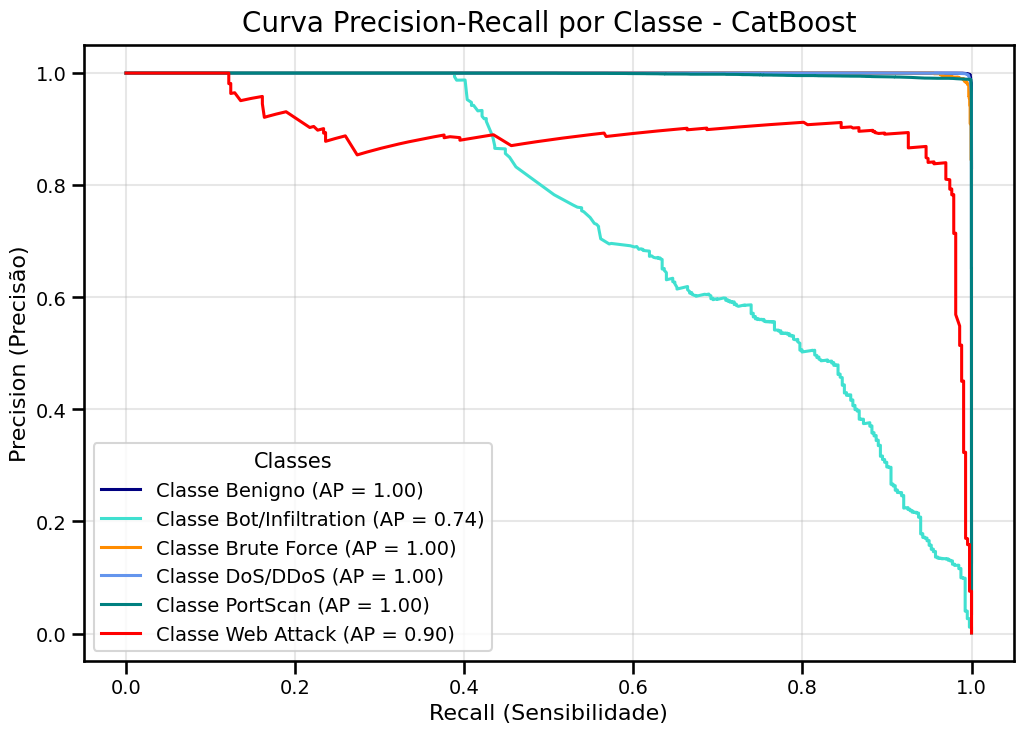

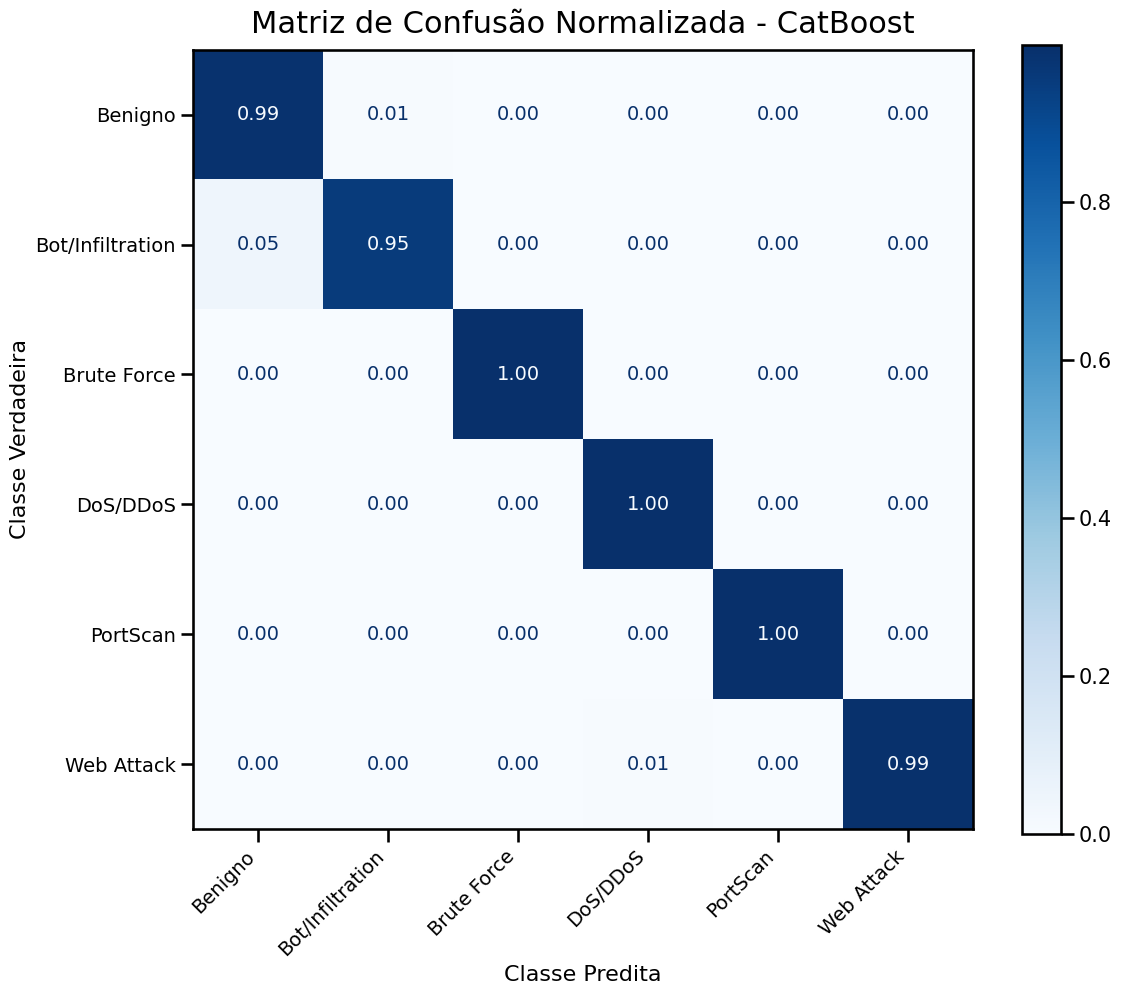

In [ ]:
nome_vice = "CatBoost"
if nome_vice not in modelos:
    raise ValueError("Modelo 'CatBoost' não encontrado no dicionário de modelos.")
modelo_vice = modelos[nome_vice]

os.makedirs("imagens_vice", exist_ok=True)

sns.set_context("talk", font_scale=1.25)
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 22,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
    'figure.titlesize': 24,
    'figure.figsize': (14, 10),
    'axes.titlepad': 12
})

# 1 curva de Aprendizado
print(f"Gerando Curva de Aprendizado para o vice: {nome_vice}")
if isinstance(X_train_res, pd.DataFrame):
    X_lc = X_train_res.sample(frac=0.1, random_state=42)
    y_lc = y_train_res.sample(frac=0.1, random_state=42)
else:
    idx = np.random.choice(len(X_train_res), int(len(X_train_res)*0.1), replace=False)
    X_lc = X_train_res[idx]
    y_lc = y_train_res[idx]

ts, tr_scores, te_scores = learning_curve(
    modelo_vice, X_lc, y_lc, cv=3, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
 )
tr_mean = np.mean(tr_scores, axis=1)
tr_std = np.std(tr_scores, axis=1)
te_mean = np.mean(te_scores, axis=1)
te_std = np.std(te_scores, axis=1)

plt.figure(figsize=(12, 7))
plt.plot(ts, tr_mean, 'o-', color="r", label="Score Treino", linewidth=2.2)
plt.plot(ts, te_mean, 'o-', color="g", label="Score Validação Cruzada", linewidth=2.2)
plt.fill_between(ts, tr_mean - tr_std, tr_mean + tr_std, alpha=0.12, color="r")
plt.fill_between(ts, te_mean - te_std, te_mean + te_std, alpha=0.12, color="g")
plt.title(f"Curva de Aprendizado - {nome_vice}", fontsize=20, pad=10)
plt.xlabel("Tamanho do Conjunto de Treino", fontsize=16)
plt.ylabel("Acurácia", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc="best", fontsize=14, title="Conjunto", title_fontsize=15)
plt.grid(alpha=0.3)
plt.savefig(f'imagens_vice/curva_de_aprendizado_{nome_vice}.pdf', dpi=300, bbox_inches='tight')
plt.show()

# 2 curvas ROC e AUC (Multiclasse)
classes = label_encoder.classes_
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=range(n_classes))
if hasattr(modelo_vice, "predict_proba"):
    y_score = modelo_vice.predict_proba(X_test_selecionado)
else:
    y_score = modelo_vice.decision_function(X_test_selecionado)

fpr = {}
tpr = {}
roc_auc = {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'ROC {classes[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title(f'Curvas ROC Multiclasse - {nome_vice}')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig(f'imagens_vice/curvas_roc_multiclasse_{nome_vice}.pdf', dpi=300, bbox_inches='tight')
plt.show()

#============================================================================================================================================
classes = label_encoder.classes_
n_classes = len(classes)

# binarizar y_test e previsões
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# pegar probabilidades (necessário para ROC)

if hasattr(modelo_vice, "predict_proba"):
    y_score = modelo_vice.predict_proba(X_test_selecionado)
else:
    y_score = modelo_vice.decision_function(X_test_selecionado)

# calcular FPR, TPR e AUC para cada classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# plotar todas as curvas ROC
plt.figure(figsize=(12, 9))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=3,
             label=f'ROC {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2.5, label='Classificador Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos', fontsize=20, fontweight='bold')
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=20, fontweight='bold')
plt.title(f'Curvas ROC Multiclasse - {modelo_campeao_nome}', fontsize=24, fontweight='bold', pad=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(loc="lower right", fontsize=14, framealpha=0.9)
plt.grid(True, alpha=0.3, linewidth=1.5)
plt.tight_layout()
plt.savefig(f'imagens_artigo/curvas_roc_multiclasse_{modelo_campeao_nome}.pdf', dpi=300, bbox_inches='tight')
plt.show()
#============================================================================================================================================


# 3 curvas Precision-Recall
precision = {}
recall = {}
average_precision = {}
plt.figure(figsize=(12, 8))
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal', 'red', 'purple'])
for i, color in zip(range(n_classes), colors):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(recall[i], precision[i], color=color, lw=2.2,
             label='Classe {0} (AP = {1:0.2f})'.format(classes[i], average_precision[i]))
plt.xlabel('Recall (Sensibilidade)', fontsize=16)
plt.ylabel('Precision (Precisão)', fontsize=16)
plt.title(f'Curva Precision-Recall por Classe - {nome_vice}', fontsize=20, pad=10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc="lower left", fontsize=14, title="Classes", title_fontsize=15)
plt.grid(alpha=0.3)
plt.savefig(f'imagens_vice/curva_precision_recall_{nome_vice}.pdf', dpi=300, bbox_inches='tight')
plt.show()

# 4 matriz de Confusão Normalizada
y_pred_vice = modelo_vice.predict(X_test_selecionado)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_vice, normalize='true',
    display_labels=label_encoder.classes_, cmap='Blues', values_format=".2f", ax=ax
)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Classe Predita", fontsize=16)
plt.ylabel("Classe Verdadeira", fontsize=16)
plt.title(f"Matriz de Confusão Normalizada - {nome_vice}", fontsize=22, pad=12)
plt.tight_layout()
plt.savefig(f'imagens_vice/matriz_confusao_normalizada_{nome_vice}.pdf', dpi=300, bbox_inches='tight')
plt.show()
